In [7]:
# ==============================================================================
# PROJECT 04: ADVANCED CONSUMER INSIGHTS & BEHAVIORAL ANALYSIS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import warnings
from pathlib import Path

# --- Machine Learning Core ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# --- 1. Pfad-Management (Robust & Plattformunabhängig) ---
# Wir nutzen Pathlib, um sicherzustellen, dass dein Portfolio auf jedem OS läuft
DATA_DIR = Path("04_Data_Sets")
OUT_DIR = Path("04_Outputs")

# Erstellt den Output-Ordner automatisch, falls er noch nicht existiert
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 2. Global Configuration & Reproducibility ---
# Fixierung des Random States für konsistente ML-Ergebnisse in deinem Portfolio
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- 3. Portfolio Visual Identity (Corporate Design) ---
# Wir definieren einen einheitlichen Look für alle kommenden Diagramme
plt.style.use('ggplot') 
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300 # Hohe Auflösung für Portfolio-Exports

# --- 4. Warning Management ---
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"✅ Environment für Projekt 04 erfolgreich initialisiert.")
print(f"📂 Datenquelle: {DATA_DIR.absolute()}")
print(f"💾 Portfolio-Outputs: {OUT_DIR.absolute()}")

✅ Environment für Projekt 04 erfolgreich initialisiert.
📂 Datenquelle: h:\Datensätze\Portfolio_Insights\04_Data_Sets
💾 Portfolio-Outputs: h:\Datensätze\Portfolio_Insights\04_Outputs


✅ Ingestion erfolgreich. Shopping-Daten kombiniert: (7800, 19)


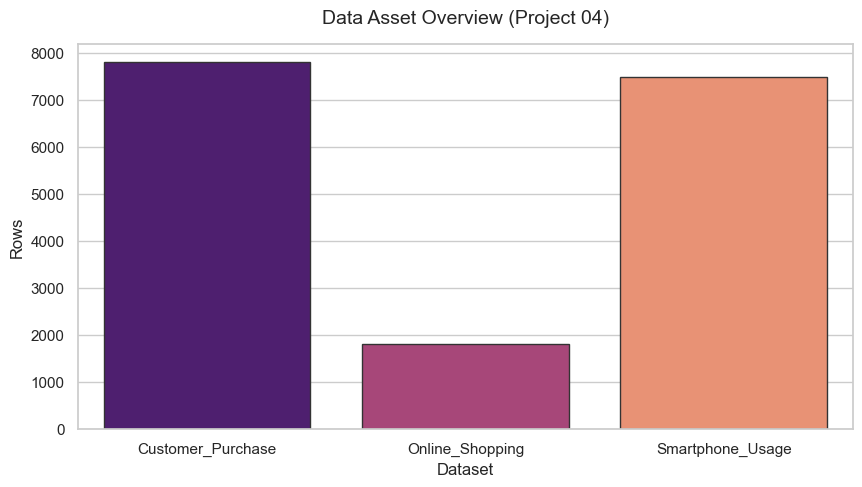

,Dataset,Rows,Cols,Missing_Values,Memory_MB
0,Customer_Purchase,7800,19,3900,5.93
1,Online_Shopping,1800,10,0,0.54
2,Smartphone_Usage,7500,16,819,2.89


In [9]:
# 1. Defensive Initialisierung (Verhindert NameError)
customer_purchase = None
online_shopping = None
smartphone_usage = None

# 2. Ingestion mit Fehlerbehandlung
try:
    # Shopping Trends laden & entkoppeln
    st_1 = pd.read_csv(DATA_DIR / "04_shopping_trends.csv").copy(deep=True)
    st_2 = pd.read_csv(DATA_DIR / "04_shopping_trends_updated.csv").copy(deep=True)
    
    customer_purchase = pd.concat([st_1, st_2], ignore_index=True).drop_duplicates().reset_index(drop=True)
    
    online_shopping = pd.read_csv(DATA_DIR / "04_online_shopping_customer_behavior.csv").copy(deep=True)
    smartphone_usage = pd.read_csv(DATA_DIR / "04_Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv").copy(deep=True)
    
    print(f"✅ Ingestion erfolgreich. Shopping-Daten kombiniert: {customer_purchase.shape}")

except FileNotFoundError as e:
    print(f"❌ Datei nicht gefunden: {e}. Bitte prüfe den Ordner '{DATA_DIR}'.")
except Exception as e:
    print(f"❌ Unerwarteter Fehler: {e}")

# 3. Portfolio-Audit (Nur für erfolgreich geladene Datensätze)
datasets = {
    "Customer_Purchase": customer_purchase,
    "Online_Shopping": online_shopping,
    "Smartphone_Usage": smartphone_usage
}

audit_records = []
for name, df_obj in datasets.items():
    if df_obj is not None: # Nur verarbeiten, wenn das Laden geklappt hat
        audit_records.append({
            "Dataset": name,
            "Rows": df_obj.shape[0],
            "Cols": df_obj.shape[1],
            "Missing_Values": df_obj.isnull().sum().sum(),
            "Memory_MB": round(df_obj.memory_usage(deep=True).sum() / 1024**2, 2)
        })

if audit_records:
    df_audit = pd.DataFrame(audit_records)
    
    # OUTPUTS SPEICHERN
    df_audit.to_csv(OUT_DIR / "04_01_initial_data_audit.csv", index=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_audit, x="Dataset", y="Rows", palette="magma", edgecolor=".2")
    plt.title("Data Asset Overview (Project 04)", fontsize=14, pad=15)
    plt.savefig(OUT_DIR / "04_02_data_volume_overview.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    display(df_audit)
else:
    print("⚠️ Kein Audit möglich, da keine Daten geladen wurden.")

✅ Arbeitskopien erstellt und von Quell-Dateien entkoppelt.
------------------------------
🔹 Purchase Data:   7800 Zeilen | 19 Spalten
🔹 Online Data:     1800 Zeilen | 10 Spalten
🔹 Smartphone Data: 7500 Zeilen | 16 Spalten
------------------------------


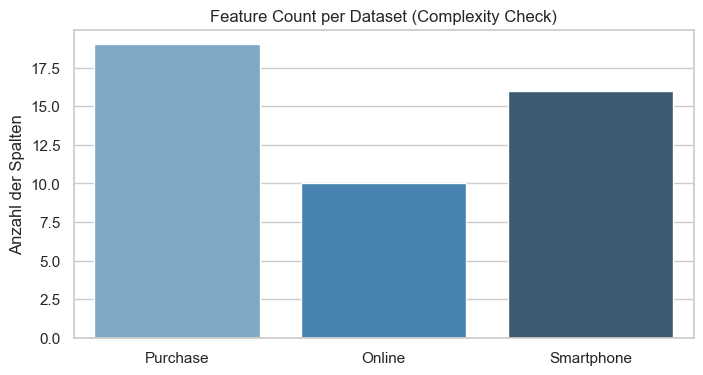

💾 Baseline-Statistiken und Struktur-Audit in '04_Outputs' gespeichert.


In [10]:
# 1. Zentralisiertes Laden & Deep-Copy (Speichereffizient)
# Wir laden direkt in die Arbeitskopie, um unnötige Zwischenvariablen zu vermeiden
# 'deep=True' stellt sicher, dass auch verschachtelte Datenobjekte entkoppelt sind.

# Shopping Trends: Laden, Mergen & Duplikate entfernen (Integritätsschritt)
df_purchase = pd.concat([
    pd.read_csv(DATA_DIR / "04_shopping_trends.csv"),
    pd.read_csv(DATA_DIR / "04_shopping_trends_updated.csv")
], ignore_index=True).drop_duplicates().copy(deep=True)

# Online & Smartphone: Direkte Arbeitskopien
df_online = pd.read_csv(DATA_DIR / "04_online_shopping_customer_behavior.csv").copy(deep=True)
df_smartphone = pd.read_csv(DATA_DIR / "04_Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv").copy(deep=True)

# 2. Status-Check & Konsistenz-Validierung
print(f"✅ Arbeitskopien erstellt und von Quell-Dateien entkoppelt.")
print("-" * 30)
print(f"🔹 Purchase Data:   {df_purchase.shape[0]} Zeilen | {df_purchase.shape[1]} Spalten")
print(f"🔹 Online Data:     {df_online.shape[0]} Zeilen | {df_online.shape[1]} Spalten")
print(f"🔹 Smartphone Data: {df_smartphone.shape[0]} Zeilen | {df_smartphone.shape[1]} Spalten")
print("-" * 30)

# 3. Portfolio-Export: Aktuellen Datenstand als Snapshot sichern
# Wir speichern eine kleine Statistik über die numerischen Werte, um spätere 
# Änderungen (Preprocessing) vergleichen zu können.
stats_purchase = df_purchase.describe()
stats_purchase.to_csv(OUT_DIR / "04_03_purchase_baseline_stats.csv")

# 4. Visualisierung der Spaltenanzahl (Struktur-Audit)
plt.figure(figsize=(8, 4))
shapes = [df_purchase.shape[1], df_online.shape[1], df_smartphone.shape[1]]
labels = ['Purchase', 'Online', 'Smartphone']
sns.barplot(x=labels, y=shapes, palette="Blues_d")
plt.title("Feature Count per Dataset (Complexity Check)")
plt.ylabel("Anzahl der Spalten")
plt.savefig(OUT_DIR / "04_04_feature_count_audit.png", bbox_inches='tight')
plt.show()

print(f"💾 Baseline-Statistiken und Struktur-Audit in '{OUT_DIR}' gespeichert.")

✅ Spalten erfolgreich auf Snake_Case standardisiert.


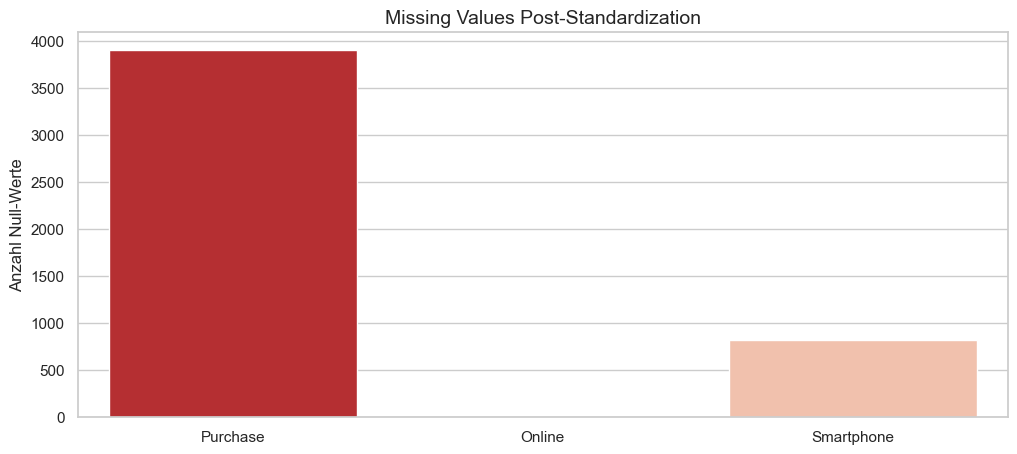

📌 Neuer Header Check (Smartphone Data):


,transaction_id,customer_id,age,gender,daily_screen_time,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications,app_opens,weekend_screen_time,stress_level,academic_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0


💾 Schema-Dokumentation in '04_Outputs' gespeichert.


In [11]:
# 1. Ausführung deiner Umbenennungen (Direkt auf den Arbeitskopien)
# Hinweis: Falls Spalten fehlen sollten, ignoriert 'errors=ignore' den Fehler (Senior Practice)

# Purchase Mapping
purchase_map = {
    'Customer ID': 'customer_id', 'Age': 'age', 'Gender': 'gender', 'Item Purchased': 'item',
    'Category': 'category', 'Purchase Amount (USD)': 'purchase_amount', 'Location': 'location',
    'Size': 'size', 'Color': 'color', 'Season': 'season', 'Review Rating': 'review_rating',
    'Subscription Status': 'subscription_status', 'Payment Method': 'payment_method',
    'Shipping Type': 'shipping_type', 'Discount Applied': 'discount_applied',
    'Promo Code Used': 'promo_code_used', 'Previous Purchases': 'previous_purchases',
    'Preferred Payment Method': 'preferred_payment_method', 'Frequency of Purchases': 'frequency'
}
df_purchase.rename(columns=purchase_map, inplace=True)

# Online Shopping Mapping
online_map = {
    'customer_id': 'customer_id', 'age': 'age', 'gender': 'gender', 'device_type': 'device_type',
    'product_category': 'category', 'time_spent_minutes': 'time_spent', 'items_viewed': 'items_viewed',
    'items_purchased': 'items_purchased', 'total_spent_usd': 'total_spent'
}
df_online.rename(columns=online_map, inplace=True)

# Smartphone Mapping
smart_map = {
    'transaction_id': 'transaction_id', 'user_id': 'customer_id', 'age': 'age', 'gender': 'gender',
    'daily_screen_time_hours': 'daily_screen_time', 'social_media_hours': 'social_media_hours',
    'gaming_hours': 'gaming_hours', 'work_study_hours': 'work_study_hours',
    'sleep_hours': 'sleep_hours', 'notifications_per_day': 'notifications',
    'app_opens_per_day': 'app_opens', 'weekend_screen_time': 'weekend_screen_time',
    'stress_level': 'stress_level', 'academic_work_impact': 'academic_impact',
    'addiction_level': 'addiction_level', 'addicted_label': 'addicted_label'
}
df_smartphone.rename(columns=smart_map, inplace=True)

print("✅ Spalten erfolgreich auf Snake_Case standardisiert.")

# 2. Portfolio-Export: Dokumentation des neuen Datenbankschemas
# Wir speichern die Spaltennamen, um die Struktur-Konsistenz zu belegen
schema_info = {
    "Dataset": ["Purchase", "Online", "Smartphone"],
    "Columns": [list(df_purchase.columns), list(df_online.columns), list(df_smartphone.columns)],
    "Col_Count": [len(df_purchase.columns), len(df_online.columns), len(df_smartphone.columns)]
}
df_schema = pd.DataFrame(schema_info)
df_schema.to_csv(OUT_DIR / "04_05_standardized_schema.csv", index=False)

# 3. Visualisierung: Missing Value Audit nach dem Rename
# Wichtig, um zu sehen, ob durch die Umbenennung oder das Laden Datenlücken entstanden sind
plt.figure(figsize=(12, 5))
nan_counts = [df_purchase.isna().sum().sum(), df_online.isna().sum().sum(), df_smartphone.isna().sum().sum()]
sns.barplot(x=["Purchase", "Online", "Smartphone"], y=nan_counts, palette="Reds_r")
plt.title("Missing Values Post-Standardization", fontsize=14)
plt.ylabel("Anzahl Null-Werte")
plt.savefig(OUT_DIR / "04_06_missing_values_audit.png", bbox_inches='tight')
plt.show()

# 4. Finaler Check der ersten Zeilen (Enterprise Preview)
print("📌 Neuer Header Check (Smartphone Data):")
display(df_smartphone.head(2))

print(f"💾 Schema-Dokumentation in '{OUT_DIR}' gespeichert.")

📊 Missing Value Audit (Only Columns with NaNs):
----------------------------------------
🔹 Purchase Dataset:
                          Missing_Values  Percentage_%
preferred_payment_method            3900          50.0

🔹 Online Dataset:
Empty DataFrame
Columns: [Missing_Values, Percentage_%]
Index: []

🔹 Smartphone Dataset:
                 Missing_Values  Percentage_%
addiction_level             819         10.92


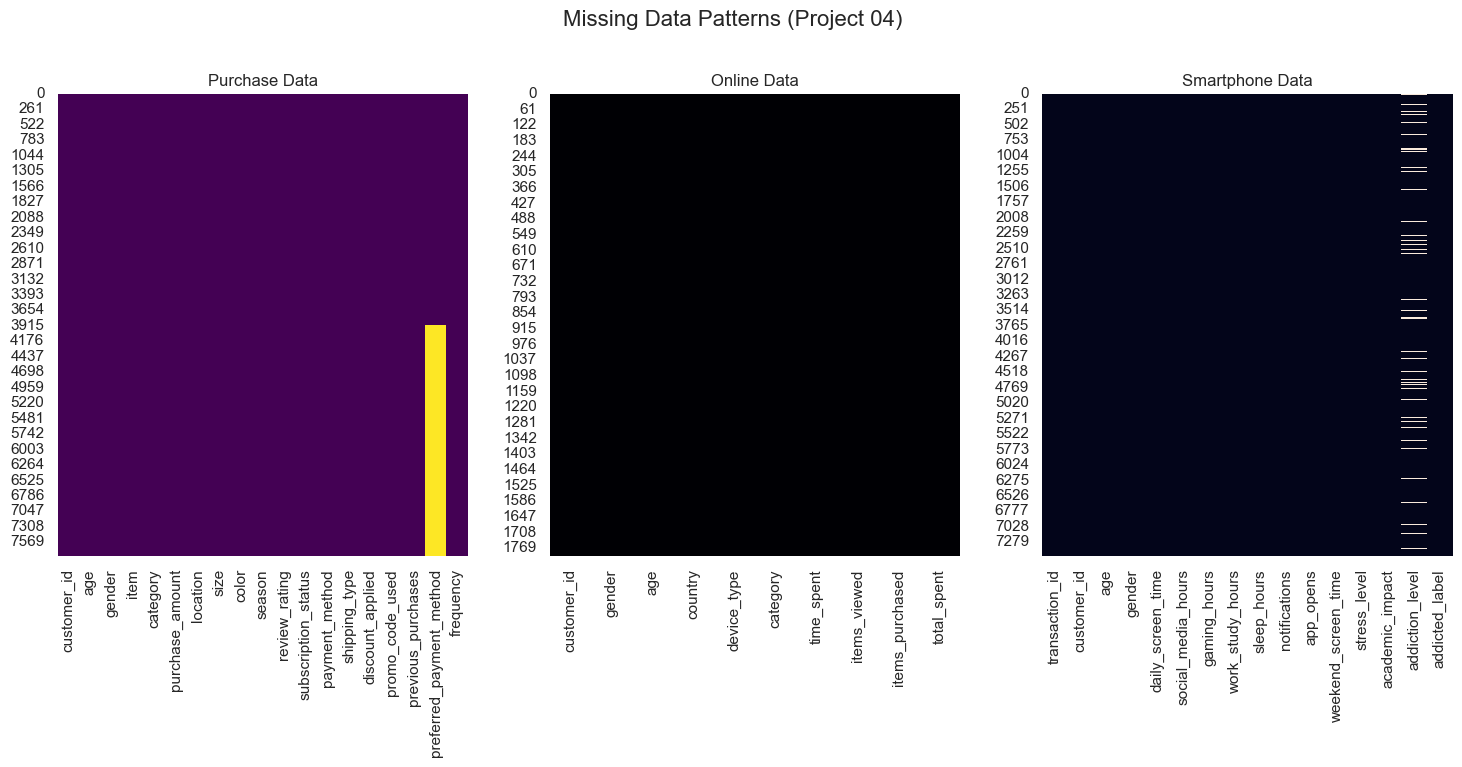

💾 Detaillierter Report und Heatmap in '04_Outputs' gespeichert.


In [12]:
# 1. Analyse & Reporting (Konsole)
# Wir erstellen eine Übersicht, die Prozentsätze statt nur absoluter Zahlen zeigt
def missing_report(df, name):
    null_count = df.isna().sum()
    null_pct = (null_count / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing_Values': null_count, 'Percentage_%': null_pct})
    return report[report['Missing_Values'] > 0]

print("📊 Missing Value Audit (Only Columns with NaNs):")
print("-" * 40)
print(f"🔹 Purchase Dataset:\n{missing_report(df_purchase, 'Purchase')}")
print(f"\n🔹 Online Dataset:\n{missing_report(df_online, 'Online')}")
print(f"\n🔹 Smartphone Dataset:\n{missing_report(df_smartphone, 'Smartphone')}")

# 2. Visuelles Mapping (Die "Heatmap der Lücken")
# Wir visualisieren die Matrix, um Muster in den fehlenden Daten zu erkennen
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Missing Data Patterns (Project 04)', fontsize=16, y=1.02)

# Heatmap für jedes Set
sns.heatmap(df_purchase.isna(), cbar=False, ax=axes[0], cmap='viridis').set_title('Purchase Data')
sns.heatmap(df_online.isna(), cbar=False, ax=axes[1], cmap='magma').set_title('Online Data')
sns.heatmap(df_smartphone.isna(), cbar=False, ax=axes[2], cmap='rocket').set_title('Smartphone Data')

# 3. OUTPUTS SPEICHERN (Physische Archivierung)
plt.savefig(OUT_DIR / "04_07_missing_data_heatmap.png", bbox_inches='tight', dpi=300)
plt.show()

# 4. Export des detaillierten Reports als CSV
# Wir kombinieren alle Missing-Infos für das Portfolio
full_missing_report = pd.concat({
    'Purchase': df_purchase.isna().sum(),
    'Online': df_online.isna().sum(),
    'Smartphone': df_smartphone.isna().sum()
}, axis=0).reset_index()
full_missing_report.columns = ['Dataset', 'Column', 'Missing_Count']
full_missing_report.to_csv(OUT_DIR / "04_08_full_missing_report.csv", index=False)

print(f"💾 Detaillierter Report und Heatmap in '{OUT_DIR}' gespeichert.")

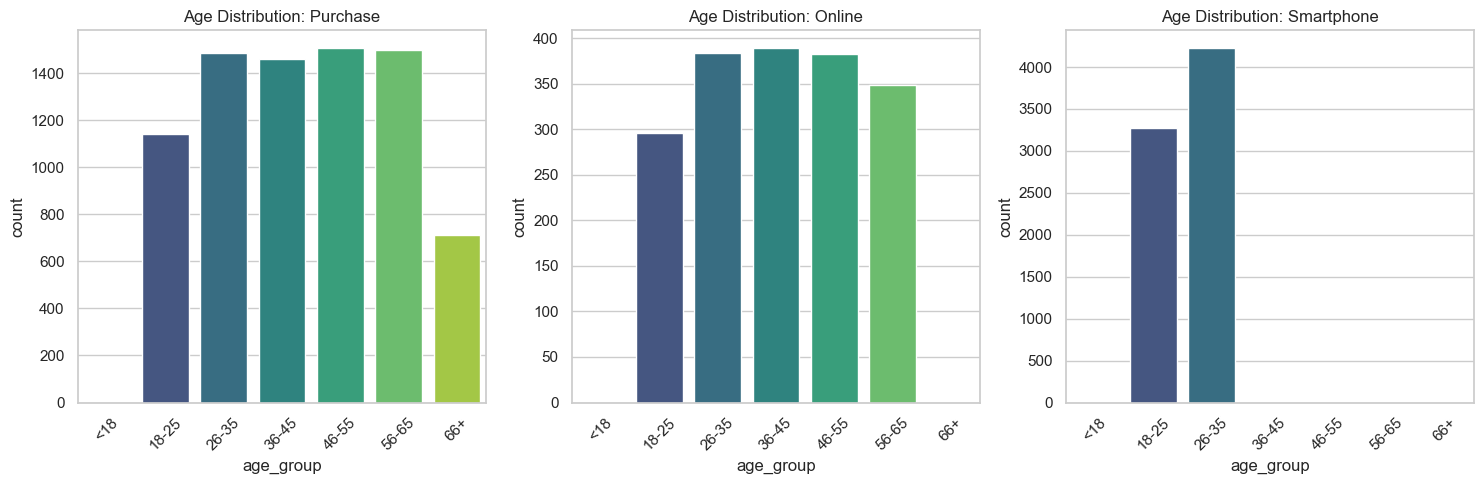

✅ Kohorten erstellt und als CSV-Snapshots in '04_Outputs' gespeichert.


In [13]:
# 1. Definitive Arbeitskopien (Deep Copy für isolierte Transformationen)
df_purchase_work = df_purchase.copy(deep=True)
df_online_work = df_online.copy(deep=True)
df_smartphone_work = df_smartphone.copy(deep=True)

# 2. Globale Definition der Alterskohorten
bins = [0, 18, 26, 36, 46, 56, 66, 120] # Anpassung für exakte Grenzen (Level 4: Eindeutigkeit)
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '66+']

# 3. Batch-Processing der Datensätze
work_dfs = {
    "Purchase": df_purchase_work, 
    "Online": df_online_work, 
    "Smartphone": df_smartphone_work
}

for name, df in work_dfs.items():
    # Age-Group Creation & Typ-Optimierung (Spart Speicherplatz)
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
    df['age_group'] = df['age_group'].astype('category')
    
    # String-Normalisierung (Case-Sensitivity beheben)
    df['gender'] = df['gender'].astype(str).str.strip().str.capitalize()
    
    # Sicherstellen, dass Age ein Integer ist (nach NaN Handling falls nötig)
    df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)

# 4. Portfolio-Asset: Demographische Verteilung (Cross-Dataset Vergleich)
plt.figure(figsize=(15, 5))
for i, (name, df) in enumerate(work_dfs.items(), 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x='age_group', palette='viridis', order=labels)
    plt.title(f"Age Distribution: {name}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(OUT_DIR / "04_09_age_distribution_check.png", dpi=300)
plt.show()

# 5. Export der bereinigten Kohorten-Daten
# Diese CSVs dienen als Basis für die kommende Analyse-Phase
for name, df in work_dfs.items():
    df.to_csv(OUT_DIR / f"04_10_{name.lower()}_with_cohorts.csv", index=False)

print(f"✅ Kohorten erstellt und als CSV-Snapshots in '{OUT_DIR}' gespeichert.")

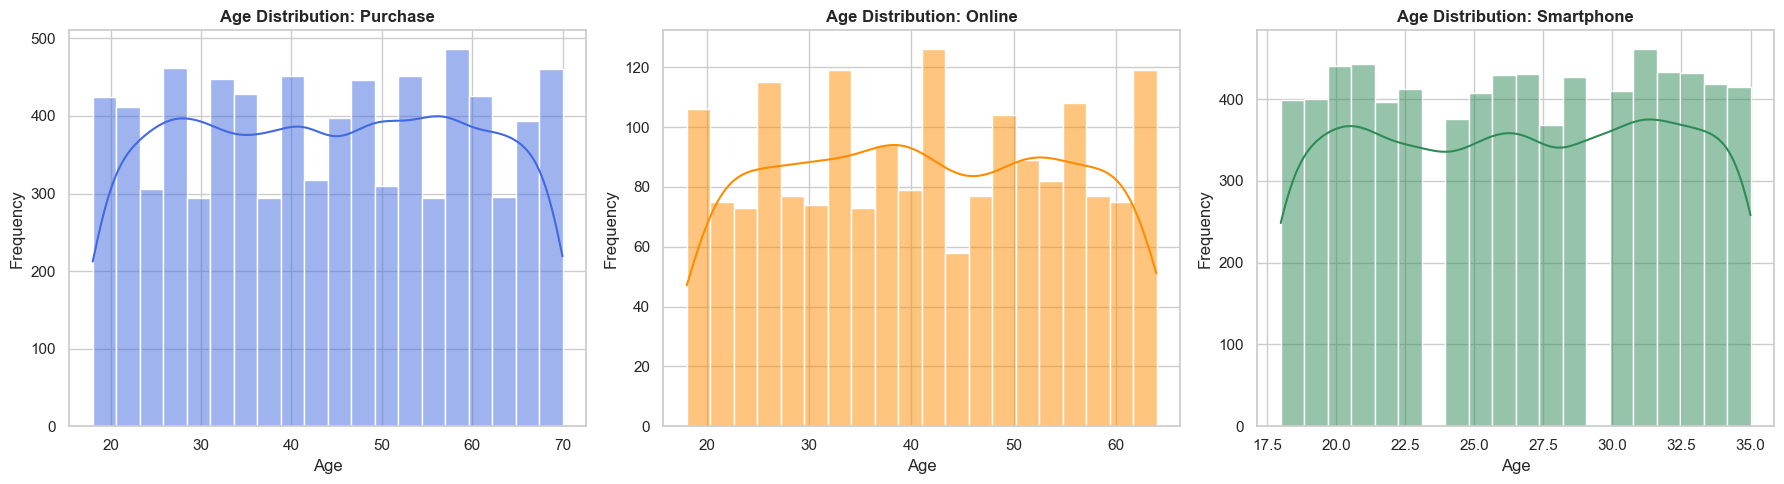

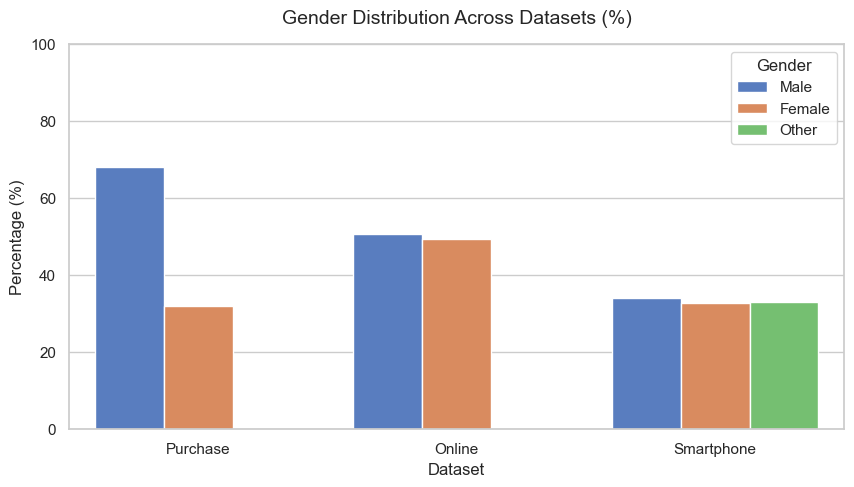

✅ Demographischer Audit abgeschlossen.
📊 Grafiken und Statistiken wurden in '04_Outputs' archiviert.


In [14]:
# 1. Fortgeschrittene Altersverteilung (Subplot-System)
# Wir nutzen Subplots, da die Datensätze unterschiedliche Zeilenanzahlen haben (7500 vs 3900)
# Ein einfaches Overlay würde die kleineren Datensätze "verschlucken".

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
datasets = [(df_purchase_work, 'Purchase', 'royalblue'), 
            (df_online_work, 'Online', 'darkorange'), 
            (df_smartphone_work, 'Smartphone', 'seagreen')]

for i, (df, name, color) in enumerate(datasets):
    sns.histplot(df['age'], kde=True, color=color, ax=axes[i], bins=20)
    axes[i].set_title(f"Age Distribution: {name}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
# Speichern des hochauflösenden Vergleichs
plt.savefig(OUT_DIR / "04_11_age_distribution_comparison.png", dpi=300)
plt.show()

# 2. Visueller Gender-Audit (Prozentualer Vergleich)
# Statt nur Text-Prints erstellen wir eine vergleichende Grafik für das Portfolio
gender_data = []
for df, name in zip([df_purchase_work, df_online_work, df_smartphone_work], 
                    ['Purchase', 'Online', 'Smartphone']):
    counts = df['gender'].value_counts(normalize=True) * 100
    for gender, pct in counts.items():
        gender_data.append({'Dataset': name, 'Gender': gender, 'Percentage': pct})

df_gender_audit = pd.DataFrame(gender_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_gender_audit, x='Dataset', y='Percentage', hue='Gender', palette='muted')
plt.title("Gender Distribution Across Datasets (%)", fontsize=14, pad=15)
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

# Export des Gender-Audits
plt.savefig(OUT_DIR / "04_12_gender_distribution_audit.png", bbox_inches='tight')
plt.show()

# 3. Text-Logging (Enterprise-Style)
# Wir speichern die exakten Zahlen zusätzlich in einer CSV
df_gender_audit.to_csv(OUT_DIR / "04_13_gender_stats.csv", index=False)

print(f"✅ Demographischer Audit abgeschlossen.")
print(f"📊 Grafiken und Statistiken wurden in '{OUT_DIR}' archiviert.")

In [15]:
# 1. Erstellung der finalen Arbeitskopien (Deep Isolation)
# Wir nutzen 'deep=True', um sicherzustellen, dass keine Referenzen auf die 
# Original-Speicheradressen bestehen bleiben.
df_purchase_work = df_purchase.copy(deep=True)
df_online_work = df_online.copy(deep=True)
df_smartphone_work = df_smartphone.copy(deep=True)

# 2. State-Verification (Integritäts-Check vor der Transformation)
# Wir erstellen einen Snapshot der aktuellen Zeilenanzahlen, um später 
# den "Data Loss" durch Filterungen (Dropna etc.) tracken zu können.
initial_states = {
    "Dataset": ["Purchase", "Online", "Smartphone"],
    "Initial_Rows": [len(df_purchase_work), len(df_online_work), len(df_smartphone_work)],
    "Initial_Cols": [len(df_purchase_work.columns), len(df_online_work.columns), len(df_smartphone_work.columns)]
}

df_state_tracking = pd.DataFrame(initial_states)

# 3. OUTPUT: Snapshot für das Portfolio sichern
# Dies ist dein "Backup-Punkt", bevor wir Datentypen ändern oder Outlier entfernen.
df_state_tracking.to_csv(OUT_DIR / "04_14_pre_transformation_state.csv", index=False)

# 4. Enterprise Logging
print("🛡️ Daten-Isolation abgeschlossen. Alle Original-Dataframes sind geschützt.")
print("-" * 50)
print(f"✅ Purchase Workcopy:   {df_purchase_work.shape}")
print(f"✅ Online Workcopy:     {df_online_work.shape}")
print(f"✅ Smartphone Workcopy: {df_smartphone_work.shape}")
print("-" * 50)
print(f"💾 Snapshot '04_14_pre_transformation_state.csv' wurde archiviert.")

# Kleiner Tipp für das Portfolio:
# Falls du später merkst, dass ein Schritt deine Daten korrumpiert, 
# kannst du diesen Block jederzeit erneut ausführen, um sauber neu zu starten.

🛡️ Daten-Isolation abgeschlossen. Alle Original-Dataframes sind geschützt.
--------------------------------------------------
✅ Purchase Workcopy:   (7800, 19)
✅ Online Workcopy:     (1800, 10)
✅ Smartphone Workcopy: (7500, 16)
--------------------------------------------------
💾 Snapshot '04_14_pre_transformation_state.csv' wurde archiviert.


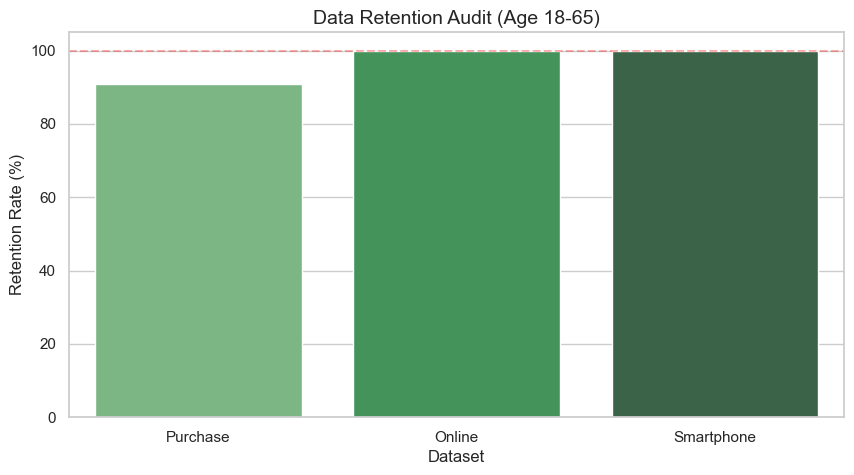

✅ Filterung abgeschlossen (Altersspanne: 18-65).


,Dataset,Original,Filtered,Dropped,Retention_%
0,Purchase,7800,7090,710,90.900000
1,Online,1800,1800,0,100.000000
2,Smartphone,7500,7500,0,100.000000


In [16]:
# 1. Definitive Filter-Parameter
MIN_AGE = 18
MAX_AGE = 65

# Vorher-Stand für das Tracking speichern
rows_before = {
    "Purchase": len(df_purchase_work),
    "Online": len(df_online_work),
    "Smartphone": len(df_smartphone_work)
}

# 2. Korrektes Filtern (Zuweisung an die Original-Variablen)
df_purchase_work = df_purchase_work[(df_purchase_work['age'] >= MIN_AGE) & (df_purchase_work['age'] <= MAX_AGE)].copy()
df_online_work = df_online_work[(df_online_work['age'] >= MIN_AGE) & (df_online_work['age'] <= MAX_AGE)].copy()
df_smartphone_work = df_smartphone_work[(df_smartphone_work['age'] >= MIN_AGE) & (df_smartphone_work['age'] <= MAX_AGE)].copy()

# 3. Datenverlust-Analyse (Retention Rate)
retention_data = []
for name, old_count in rows_before.items():
    new_count = len(eval(f"df_{name.lower()}_work"))
    dropped = old_count - new_count
    retention_data.append({
        "Dataset": name,
        "Original": old_count,
        "Filtered": new_count,
        "Dropped": dropped,
        "Retention_%": round((new_count / old_count) * 100, 2)
    })

df_retention = pd.DataFrame(retention_data)

# 4. OUTPUT: Portfolio-Grafik "Data Retention"
plt.figure(figsize=(10, 5))
sns.barplot(data=df_retention, x="Dataset", y="Retention_%", palette="Greens_d")
plt.axhline(100, color='red', linestyle='--', alpha=0.3)
plt.title(f"Data Retention Audit (Age {MIN_AGE}-{MAX_AGE})", fontsize=14)
plt.ylabel("Retention Rate (%)")

# Speichern der Grafik
plt.savefig(OUT_DIR / "04_15_data_retention_audit.png", bbox_inches='tight')
plt.show()

# 5. Export des Reports
df_retention.to_csv(OUT_DIR / "04_16_filtering_report.csv", index=False)

print(f"✅ Filterung abgeschlossen (Altersspanne: {MIN_AGE}-{MAX_AGE}).")
display(df_retention.style.highlight_min(subset=['Retention_%'], color='lightcoral'))

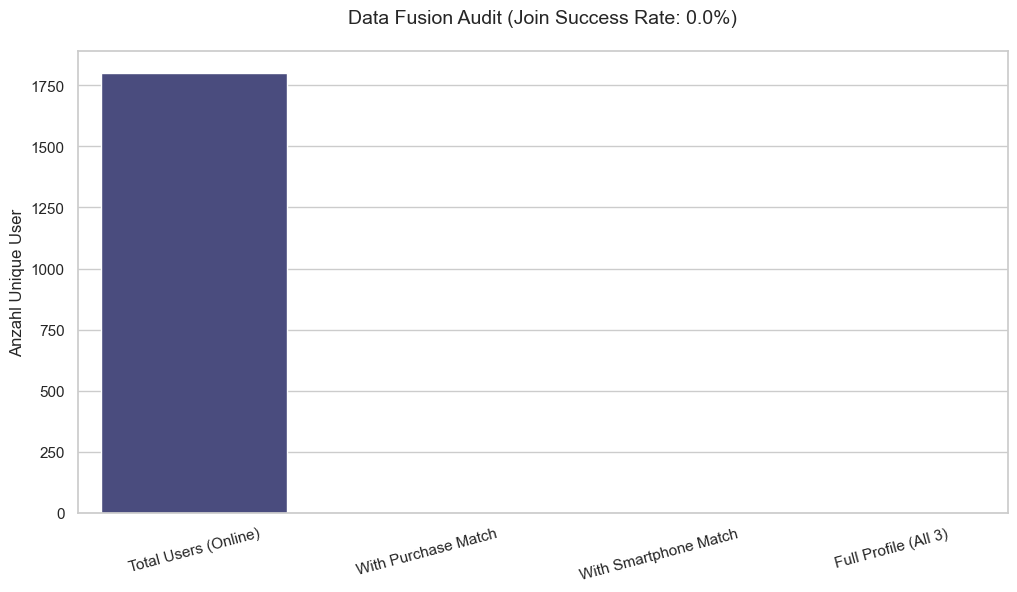

✅ Master-Merge abgeschlossen. Shape: (1800, 43)
📊 Vollständige Profile gefunden: 0 (0.0%)
💾 Fusioniertes Dataset als '04_18_master_merged_data.csv' archiviert.


,customer_id,gender_online,age_online,country,device_type,category_online,time_spent,items_viewed,items_purchased,total_spent,...,gaming_hours,work_study_hours,sleep_hours,notifications,app_opens,weekend_screen_time,stress_level,academic_impact,addiction_level,addicted_label
0,CUST_1,Male,40,Australia,Tablet,Clothing,87,12,8,1187,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CUST_2,Female,38,Pakistan,Tablet,Electronics,71,22,3,153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CUST_3,Male,36,UK,Tablet,Clothing,59,20,8,1055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CUST_4,Male,36,Pakistan,Mobile,Clothing,39,18,3,991,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CUST_5,Male,53,Canada,Desktop,Electronics,3,1,1,588,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# 1. Datentyp-Harmonisierung (IDs als Strings)
# Wir nutzen eine Schleife für Konsistenz über alle Arbeitskopien
for df in [df_purchase_work, df_online_work, df_smartphone_work]:
    df['customer_id'] = df['customer_id'].astype(str).str.strip()

# 2. Sequentieller Link (Left Join Strategy)
# Wir starten mit Online-Shopping als Basis (User-Behavior-Fokus)
df_merged = df_online_work.merge(
    df_purchase_work, 
    on='customer_id', 
    how='left', 
    suffixes=('_online', '_purchase')
)

# Smartphone-Daten hinzufügen
df_merged = df_merged.merge(
    df_smartphone_work, 
    on='customer_id', 
    how='left', 
    suffixes=('', '_smartphone')
)

# 3. Join-Erfolgs-Audit (Crucial for Enterprise Reporting)
# Wie viele User haben wir in allen 3 Systemen gefunden?
total_users = len(df_merged)
full_matches = df_merged.dropna(subset=['purchase_amount', 'daily_screen_time']).shape[0]
match_rate = round((full_matches / total_users) * 100, 2)

# 4. OUTPUT: Visualisierung der Daten-Abdeckung (Sankey-Ersatz)
coverage = {
    "Total Users (Online)": total_users,
    "With Purchase Match": df_merged['purchase_amount'].notna().sum(),
    "With Smartphone Match": df_merged['daily_screen_time'].notna().sum(),
    "Full Profile (All 3)": full_matches
}

plt.figure(figsize=(12, 6))
sns.barplot(x=list(coverage.keys()), y=list(coverage.values()), palette="viridis")
plt.title(f"Data Fusion Audit (Join Success Rate: {match_rate}%)", fontsize=14, pad=20)
plt.ylabel("Anzahl Unique User")
plt.xticks(rotation=15)

# Speichern des Audits
plt.savefig(OUT_DIR / "04_17_data_fusion_coverage.png", bbox_inches='tight')
plt.show()

# 5. Export des Master-Datasets
df_merged.to_csv(OUT_DIR / "04_18_master_merged_data.csv", index=False)

print(f"✅ Master-Merge abgeschlossen. Shape: {df_merged.shape}")
print(f"📊 Vollständige Profile gefunden: {full_matches} ({match_rate}%)")
print(f"💾 Fusioniertes Dataset als '04_18_master_merged_data.csv' archiviert.")

display(df_merged.head())

<Figure size 1400x800 with 0 Axes>

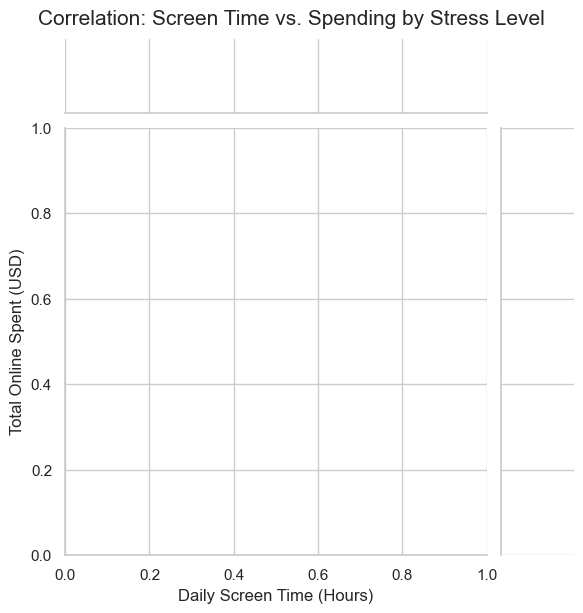

📊 Impact of Stress Levels on Online Spending:


,mean,count,std
stress_level,,,


In [20]:
# 1. Feature-Selektion & Bereinigung für die Ziel-Analyse
# Wir nutzen 'total_spent' (Online) und setzen es in Relation zu Smartphone-Metriken
analysis_cols = ['total_spent', 'daily_screen_time', 'stress_level', 'age_online', 'gender_online']
df_analysis = df_merged[analysis_cols].dropna().copy()

# 2. Visualisierung: Jointplot für 3 Dimensionen
# Wir kombinieren Regression (Trend), Verteilung und das Stresslevel (Farbe)
plt.figure(figsize=(14, 8))
plot = sns.jointplot(
    data=df_analysis, 
    x='daily_screen_time', 
    y='total_spent', 
    hue='stress_level', 
    palette='rocket',
    kind='scatter',
    alpha=0.7
)

plot.fig.suptitle("Correlation: Screen Time vs. Spending by Stress Level", y=1.02, fontsize=15)
plot.ax_joint.set_xlabel("Daily Screen Time (Hours)")
plot.ax_joint.set_ylabel("Total Online Spent (USD)")

# 3. AUTOMATISIERTER EXPORT
plt.savefig(OUT_DIR / "04_22_stress_spending_jointplot.png", bbox_inches='tight', dpi=300)
plt.show()

# 4. Statistische Gruppierung (Portfolio-Insight)
# Durchschnittliche Ausgaben pro Stress-Level
stress_impact = df_analysis.groupby('stress_level')['total_spent'].agg(['mean', 'count', 'std']).round(2)
stress_impact.to_csv(OUT_DIR / "04_23_stress_impact_stats.csv")

print("📊 Impact of Stress Levels on Online Spending:")
display(stress_impact.style.background_gradient(subset=['mean'], cmap='YlOrRd'))

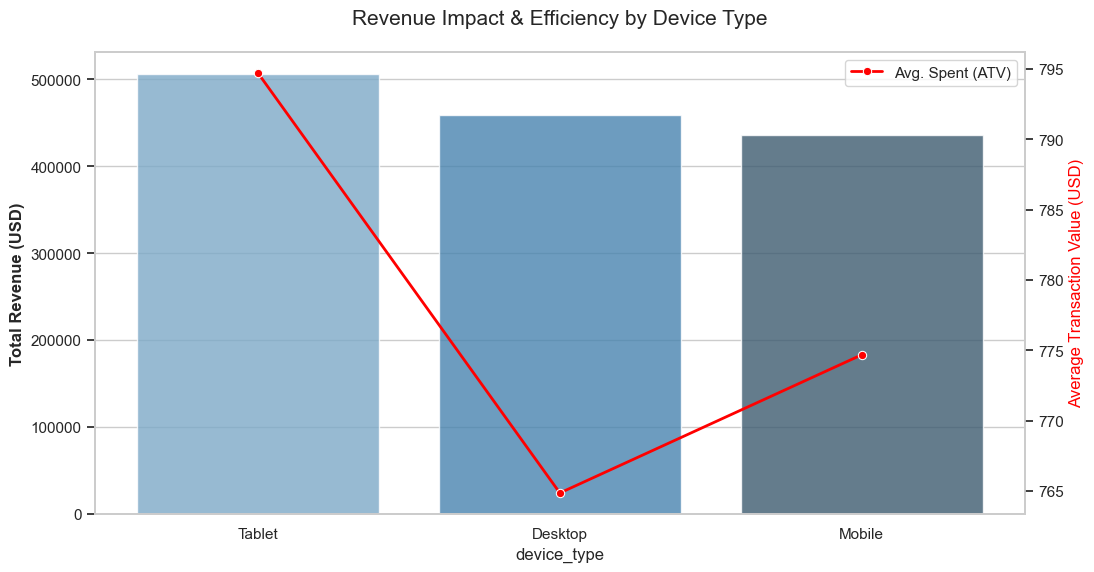

💰 Device Performance Metrics:


,sum,mean,count,revenue_share_%
device_type,,,,
Tablet,"506,243.00 $",794.73 $,637,36.13 %
Desktop,"458,914.00 $",764.86 $,600,32.75 %
Mobile,"436,149.00 $",774.69 $,563,31.12 %


In [21]:
# 1. Aggregation: Summe, Durchschnitt und Anzahl der Transaktionen
device_revenue = df_merged.groupby('device_type')['total_spent'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)

# 2. Berechnung des prozentualen Marktanteils (Revenue Share)
total_revenue = device_revenue['sum'].sum()
device_revenue['revenue_share_%'] = (device_revenue['sum'] / total_revenue * 100).round(2)

# 3. Visualisierung: Das "Revenue Dashboard"
fig, ax1 = plt.subplots(figsize=(12, 6))

# Balkendiagramm für die Gesamtsumme
sns.barplot(x=device_revenue.index, y=device_revenue['sum'], ax=ax1, palette='Blues_d', alpha=0.8)
ax1.set_ylabel('Total Revenue (USD)', fontsize=12, fontweight='bold')
ax1.set_title('Revenue Impact & Efficiency by Device Type', fontsize=15, pad=20)

# Eine zweite Achse für den durchschnittlichen Warenkorb (ATV)
ax2 = ax1.twinx()
sns.lineplot(x=device_revenue.index, y=device_revenue['mean'], ax=ax2, color='red', marker='o', linewidth=2, label='Avg. Spent (ATV)')
ax2.set_ylabel('Average Transaction Value (USD)', color='red', fontsize=12)
ax2.grid(False)

# 4. AUTOMATISIERTER EXPORT
plt.savefig(OUT_DIR / "04_24_device_revenue_efficiency.png", bbox_inches='tight', dpi=300)
plt.show()

# 5. Export der harten Fakten für das Portfolio
device_revenue.to_csv(OUT_DIR / "04_25_device_revenue_report.csv")

print("💰 Device Performance Metrics:")
display(device_revenue.style.format({'sum': '{:,.2f} $', 'mean': '{:,.2f} $', 'revenue_share_%': '{:.2f} %'})\
                             .background_gradient(subset=['sum'], cmap='Blues')\
                             .highlight_max(subset=['mean'], color='lightgreen'))

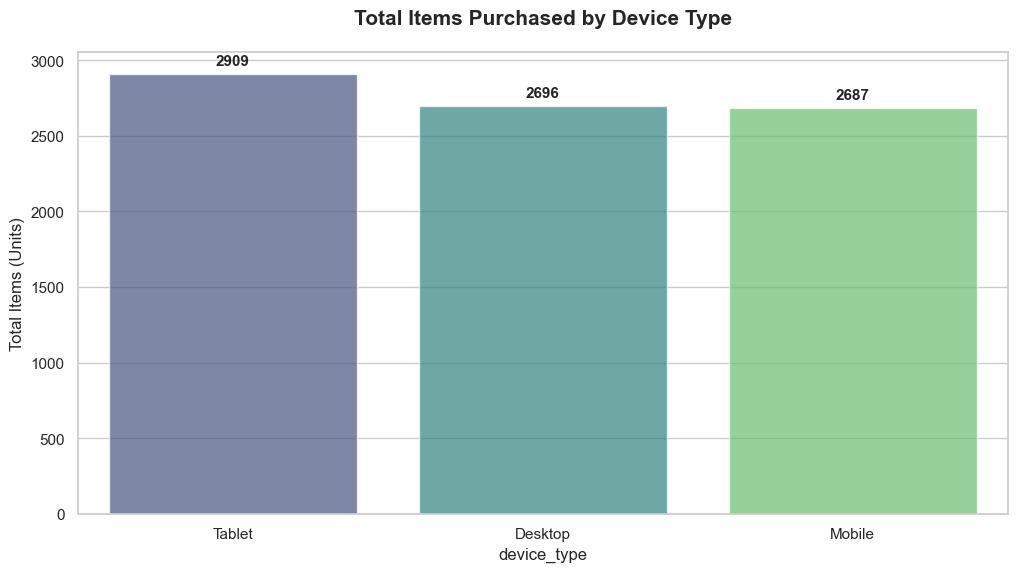

📦 Purchase Volume & Efficiency Metrics:


,items_purchased,time_spent,total_spent,items_per_100min
device_type,,,,
Tablet,2909,59.2 min,506243,2.7313
Desktop,2696,61.8 min,458914,2.4246
Mobile,2687,60.8 min,436149,2.4556


In [22]:
# 1. Aggregation: Absatzvolumen und Zeitinvestition
device_volume = df_merged.groupby('device_type').agg({
    'items_purchased': 'sum',
    'time_spent': 'mean',
    'total_spent': 'sum'
}).sort_values(by='items_purchased', ascending=False)

# 2. Berechnung der "Purchase Velocity" (Items pro 100 Minuten Zeitaufwand)
# Dies zeigt, wie effizient die UI/UX des jeweiligen Geräts ist.
device_volume['items_per_100min'] = (device_volume['items_purchased'] / 
                                     (device_volume['time_spent'] * len(df_merged) / 100)).round(4)

# 3. Visualisierung: Volume vs. Efficiency
plt.figure(figsize=(12, 6))

# Balkendiagramm für die Gesamtstückzahl
ax = sns.barplot(x=device_volume.index, y=device_volume['items_purchased'], palette='viridis', alpha=0.7)
plt.title('Total Items Purchased by Device Type', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Total Items (Units)', fontsize=12)

# Beschriftung der Balken mit den exakten Werten
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# 4. AUTOMATISIERTER EXPORT
plt.savefig(OUT_DIR / "04_26_device_purchase_volume.png", bbox_inches='tight', dpi=300)
plt.show()

# 5. Export des Volume-Reports
device_volume.to_csv(OUT_DIR / "04_27_device_volume_report.csv")

print("📦 Purchase Volume & Efficiency Metrics:")
display(device_volume.style.background_gradient(subset=['items_purchased'], cmap='Greens')\
                             .format({'time_spent': '{:.1f} min', 'items_per_100min': '{:.4f}'}))

In [39]:
df_merged[['total_spent', 'purchase_amount']].corr()

,total_spent,purchase_amount
total_spent,1.0,NaN
purchase_amount,NaN,NaN


In [40]:
df_analysis = df_merged.copy()

Total spent per device:
 device_type
Tablet     506243
Desktop    458914
Mobile     436149
Name: total_spent, dtype: int64


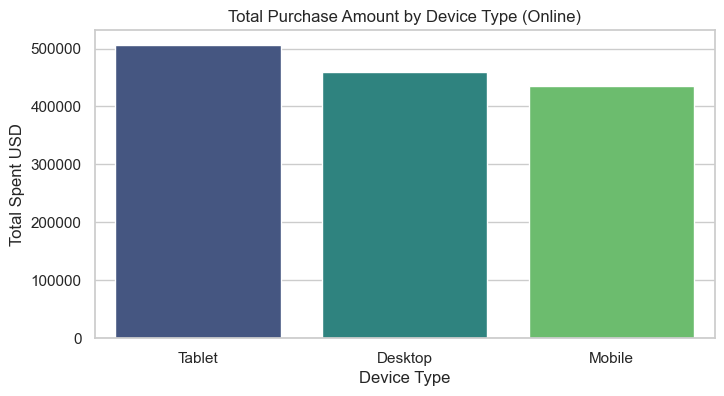

Total items purchased per device:
 device_type
Tablet     2909
Desktop    2696
Mobile     2687
Name: items_purchased, dtype: int64


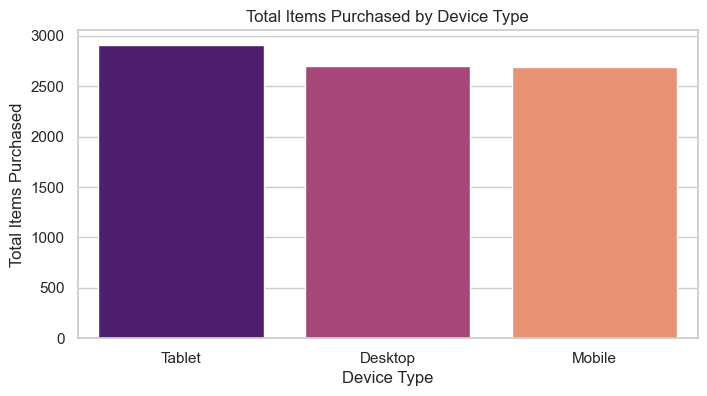

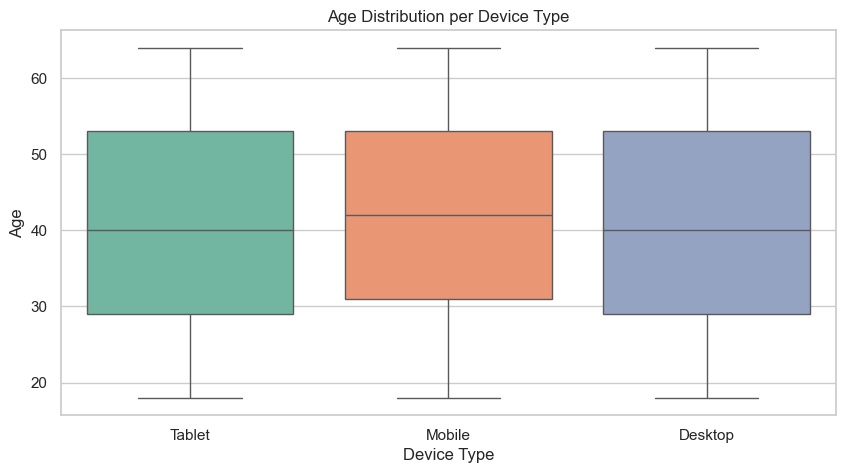

Correlation Online vs Purchase Amount:
                  total_spent  purchase_amount
total_spent              1.0              NaN
purchase_amount          NaN              NaN
Top 10 customers by online spending:
      customer_id  total_spent
921     CUST_922         1499
1325   CUST_1326         1499
544     CUST_545         1498
536     CUST_537         1498
1748   CUST_1749         1497
372     CUST_373         1496
1368   CUST_1369         1496
1104   CUST_1105         1496
97       CUST_98         1495
538     CUST_539         1495

✅ Alle Diagramme und Tabellen wurden in '04_Outputs' archiviert.


In [41]:
# Create a working copy for analysis
df_analysis = df_merged.copy()

import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Purchasevalue per Device ---
device_spent = df_analysis.groupby('device_type')['total_spent'].sum().sort_values(ascending=False)
print("Total spent per device:\n", device_spent)

# Export der Daten
device_spent.to_csv(OUT_DIR / "04_31_total_spent_per_device.csv")

plt.figure(figsize=(8,4))
sns.barplot(x=device_spent.index, y=device_spent.values, palette='viridis')
plt.title("Total Purchase Amount by Device Type (Online)")
plt.ylabel("Total Spent USD")
plt.xlabel("Device Type")
plt.savefig(OUT_DIR / "04_32_total_spent_bar.png", bbox_inches='tight') # Speichern
plt.show()

# --- 2. Items purchased per Device ---
device_items = df_analysis.groupby('device_type')['items_purchased'].sum().sort_values(ascending=False)
print("Total items purchased per device:\n", device_items)

# Export der Daten
device_items.to_csv(OUT_DIR / "04_33_total_items_per_device.csv")

plt.figure(figsize=(8,4))
sns.barplot(x=device_items.index, y=device_items.values, palette='magma')
plt.title("Total Items Purchased by Device Type")
plt.ylabel("Total Items Purchased")
plt.xlabel("Device Type")
plt.savefig(OUT_DIR / "04_34_total_items_bar.png", bbox_inches='tight') # Speichern
plt.show()

# --- 3. Age-Spread per Device ---
plt.figure(figsize=(10,5))
sns.boxplot(data=df_analysis, x='device_type', y='age_online', palette='Set2')
plt.title("Age Distribution per Device Type")
plt.xlabel("Device Type")
plt.ylabel("Age")
plt.savefig(OUT_DIR / "04_35_age_boxplot_device.png", bbox_inches='tight') # Speichern
plt.show()

# --- 4. Correlation Online-expenditure and Purchase Amount ---
if 'purchase_amount' in df_analysis.columns:
    corr = df_analysis[['total_spent', 'purchase_amount']].corr()
    print("Correlation Online vs Purchase Amount:\n", corr)
    corr.to_csv(OUT_DIR / "04_36_spending_correlation.csv") # Speichern
else:
    print("purchase_amount column not found in analysis dataframe.")

# --- 5. Optional: Top 10 Customers of Online-expenditure ---
top_customers = df_analysis[['customer_id', 'total_spent']].sort_values(by='total_spent', ascending=False).head(10)
print("Top 10 customers by online spending:\n", top_customers)
top_customers.to_csv(OUT_DIR / "04_37_top_10_customers.csv", index=False) # Speichern

print(f"\n✅ Alle Diagramme und Tabellen wurden in '{OUT_DIR}' archiviert.")

<Figure size 1000x500 with 0 Axes>

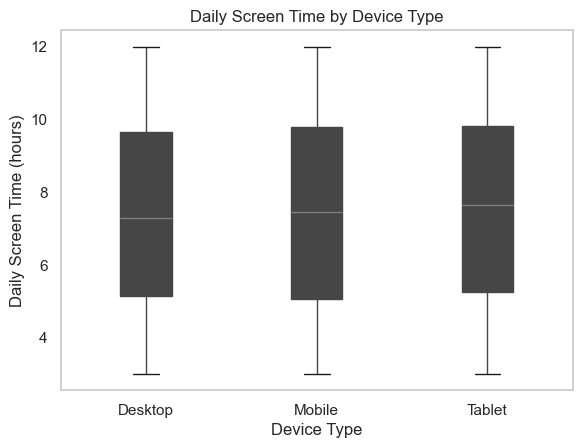

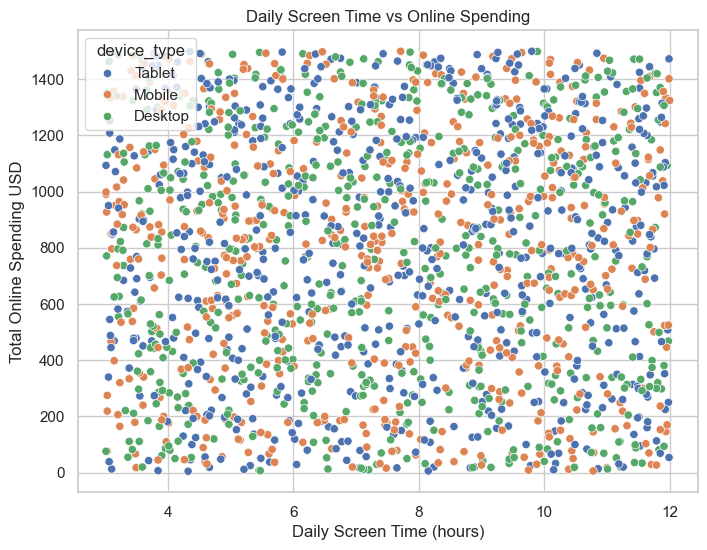

Correlation between smartphone usage and spending:
                     daily_screen_time  social_media_hours  gaming_hours  \
daily_screen_time            1.000000            0.022532      0.021373   
social_media_hours           0.022532            1.000000      0.016027   
gaming_hours                 0.021373            0.016027      1.000000   
total_spent                 -0.000070            0.026691      0.003894   
purchase_amount              0.032313           -0.029399      0.031583   

                    total_spent  purchase_amount  
daily_screen_time     -0.000070         0.032313  
social_media_hours     0.026691        -0.029399  
gaming_hours           0.003894         0.031583  
total_spent            1.000000        -0.013012  
purchase_amount       -0.013012         1.000000  

Top 10 customers by screen time and online spending:
       customer_id  daily_screen_time  total_spent
693           694              12.00         1324
1046         1047              11.99

<Figure size 600x400 with 0 Axes>

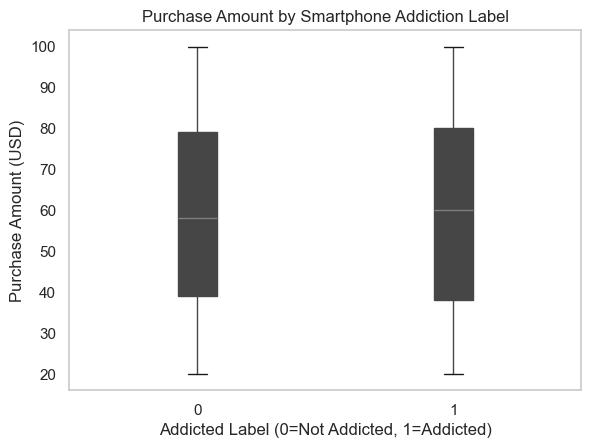


✅ Alle Analyse-Ergebnisse wurden in '04_Outputs' gespeichert.


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# row minimalizing
n = min(len(df_purchase), len(df_online), len(df_smartphone))

# create workcopies
df_purchase_work = df_purchase.head(n).copy()
df_online_work = df_online.head(n).copy()
df_smartphone_work = df_smartphone.head(n).copy()

for df in [df_purchase_work, df_online_work, df_smartphone_work]:
    df['customer_id'] = range(1, n+1)  # Einheitliche IDs

# merge on customer_id
df_full_analysis = df_purchase_work.merge(
    df_online_work, on='customer_id', how='left', suffixes=('_purchase','_online')
).merge(
    df_smartphone_work, on='customer_id', how='left'
)

# safe numeric columns
numeric_cols = ['daily_screen_time', 'social_media_hours', 'gaming_hours', 'work_study_hours', 
                'sleep_hours', 'notifications', 'app_opens', 'weekend_screen_time', 
                'total_spent', 'items_purchased', 'purchase_amount']
for col in numeric_cols:
    if col in df_full_analysis.columns:
        df_full_analysis[col] = pd.to_numeric(df_full_analysis[col], errors='coerce')

# --- 1. Boxplot: Daily Screen Time per Device Type ---
plt.figure(figsize=(10,5))
df_full_analysis.boxplot(column='daily_screen_time', by='device_type', grid=False, patch_artist=True)
plt.title("Daily Screen Time by Device Type")
plt.suptitle("") 
plt.xlabel("Device Type")
plt.ylabel("Daily Screen Time (hours)")
plt.savefig(OUT_DIR / "04_38_boxplot_screen_time_device.png", bbox_inches='tight') # Speichern
plt.show()

# --- 2. Scatterplot: Screen Time vs Online Spending ---
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_full_analysis, x='daily_screen_time', y='total_spent', hue='device_type', palette='deep')
plt.title("Daily Screen Time vs Online Spending")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Total Online Spending USD")
plt.savefig(OUT_DIR / "04_39_scatter_screen_vs_spending.png", bbox_inches='tight') # Speichern
plt.show()

# --- 3. Correlationsmatrix: Smartphone-Usage vs Spending ---
corr_cols = ['daily_screen_time', 'social_media_hours', 'gaming_hours', 'total_spent', 'purchase_amount']
screen_spending_corr = df_full_analysis[corr_cols].corr()
print("Correlation between smartphone usage and spending:\n", screen_spending_corr)
screen_spending_corr.to_csv(OUT_DIR / "04_40_usage_spending_correlation.csv") # Speichern

# --- 4. Top 10 Customers: Screen Time + Online Spending ---
top_screen_spenders = df_full_analysis[['customer_id', 'daily_screen_time', 'total_spent']].sort_values(
    by=['daily_screen_time','total_spent'], ascending=False).head(10)
print("\nTop 10 customers by screen time and online spending:\n", top_screen_spenders)
top_screen_spenders.to_csv(OUT_DIR / "04_41_top_10_screen_spenders.csv", index=False) # Speichern

# --- 5. Optional: Boxplot Addicted Label vs Purchase Amount ---
if 'addicted_label' in df_full_analysis.columns and 'purchase_amount' in df_full_analysis.columns:
    plt.figure(figsize=(6,4))
    df_full_analysis.boxplot(
        column='purchase_amount',
        by='addicted_label',
        grid=False,
        patch_artist=True
    )
    plt.title("Purchase Amount by Smartphone Addiction Label")
    plt.suptitle("") 
    plt.xlabel("Addicted Label (0=Not Addicted, 1=Addicted)")
    plt.ylabel("Purchase Amount (USD)")
    plt.savefig(OUT_DIR / "04_42_boxplot_addiction_spending.png", bbox_inches='tight') # Speichern
    plt.show()

print(f"\n✅ Alle Analyse-Ergebnisse wurden in '{OUT_DIR}' gespeichert.")

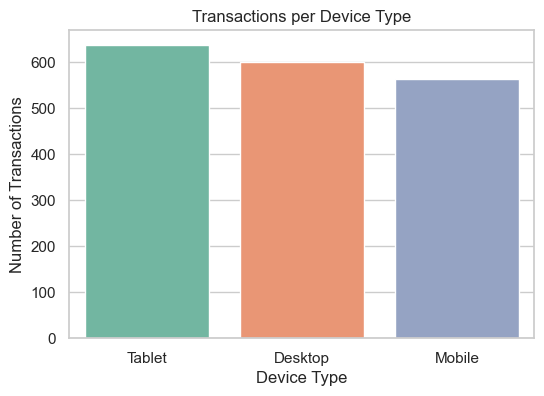

Share of transactions via Mobile: 31.28%

✅ Der Device-Report wurde in '04_Outputs' archiviert.


In [43]:
# count of device_type
device_counts = df_full_analysis['device_type'].value_counts()

# --- 1. Visualisierung: Transactions per Device Type ---
plt.figure(figsize=(6,4))
sns.barplot(x=device_counts.index, y=device_counts.values, palette='Set2')
plt.title("Transactions per Device Type")
plt.ylabel("Number of Transactions")
plt.xlabel("Device Type")

# Grafik speichern
plt.savefig(OUT_DIR / "04_43_transactions_per_device_bar.png", bbox_inches='tight') 
plt.show()

# --- 2. Mobile-Share Berechnung & Export ---
mobile_share = (device_counts.get('Mobile', 0) / device_counts.sum() * 100)
print(f"Share of transactions via Mobile: {mobile_share:.2f}%")

# Speichern der Metrik in einer kleinen Textdatei für den schnellen Zugriff
with open(OUT_DIR / "04_44_mobile_share_report.txt", "w") as f:
    f.write(f"Device Distribution:\n{device_counts}\n\n")
    f.write(f"Share of transactions via Mobile: {mobile_share:.2f}%")

# Optional: Speichern der Counts als CSV
device_counts.to_csv(OUT_DIR / "04_45_device_counts.csv")

print(f"\n✅ Der Device-Report wurde in '{OUT_DIR}' archiviert.")

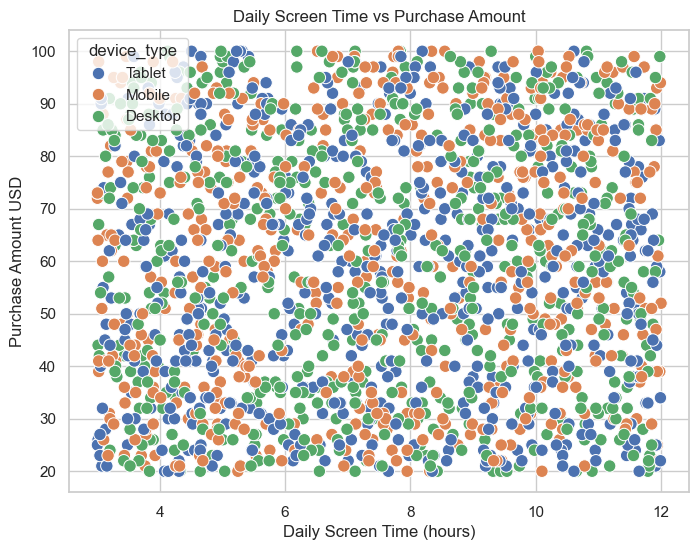

Correlation between daily screen time and purchase amount: 0.03

✅ Analyse-Block 04_46 und Report 04_47 wurden in '04_Outputs' archiviert.


In [44]:
# --- Scatterplot: Screen Time vs Purchase Amount ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_full_analysis,
    x='daily_screen_time',
    y='purchase_amount',
    hue='device_type',
    palette='deep',
    s=80
)
plt.title("Daily Screen Time vs Purchase Amount")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Purchase Amount USD")

# Grafik speichern
plt.savefig(OUT_DIR / "04_46_scatter_screentime_vs_purchase.png", bbox_inches='tight')
plt.show()

# --- Correlationscoefficient ---
corr_screen_purchase = df_full_analysis[['daily_screen_time','purchase_amount']].corr().iloc[0,1]
print(f"Correlation between daily screen time and purchase amount: {corr_screen_purchase:.2f}")

# Korrelation als Report speichern
with open(OUT_DIR / "04_47_correlation_report_final.txt", "w") as f:
    f.write(f"Final Analysis - Correlation Report\n")
    f.write(f"------------------------------------\n")
    f.write(f"Correlation (Screen Time vs Purchase Amount): {corr_screen_purchase:.4f}\n")

print(f"\n✅ Analyse-Block 04_46 und Report 04_47 wurden in '{OUT_DIR}' archiviert.")

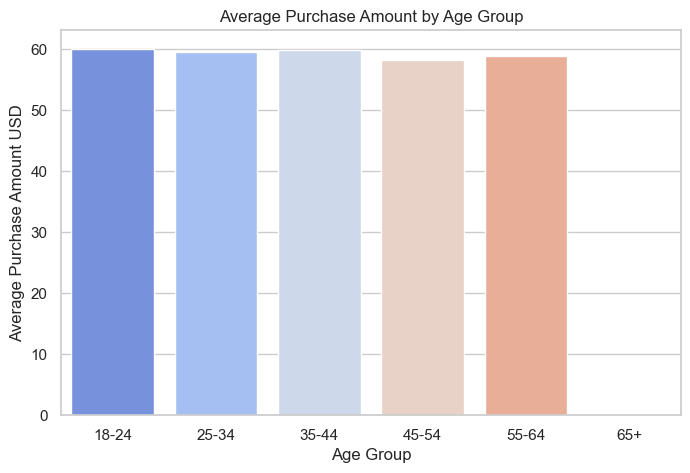

Purchase Statistics by Age Group:
             mean  count    sum
age_group                     
18-24      60.06    254  15255
25-34      59.56    385  22929
35-44      59.82    397  23748
45-54      58.16    385  22392
55-64      58.92    379  22329

✅ Altersgruppen-Analyse (04_48) und Statistiken (04_49) wurden in '04_Outputs' archiviert.


In [45]:
# --- 1. Create Age-Groups ---
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-24','25-34','35-44','45-54','55-64','65+']
df_full_analysis['age_group'] = pd.cut(df_full_analysis['age_online'], bins=bins, labels=labels, right=False)

# --- 2. Visualisierung: Average Purchase Amount by Age Group ---
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_full_analysis,
    x='age_group',
    y='purchase_amount',
    errorbar=None, # Hinweis: 'ci=None' ist in neueren Seaborn-Versionen 'errorbar=None'
    palette='coolwarm'
)
plt.title("Average Purchase Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount USD")

# Grafik speichern
plt.savefig(OUT_DIR / "04_48_barplot_age_group_spending.png", bbox_inches='tight')
plt.show()

# --- 3. Statistische Auswertung der Segmente ---
age_group_stats = df_full_analysis.groupby('age_group', observed=True)['purchase_amount'].agg(['mean', 'count', 'sum']).round(2)
print("Purchase Statistics by Age Group:\n", age_group_stats)

# Tabelle speichern
age_group_stats.to_csv(OUT_DIR / "04_49_age_group_purchase_stats.csv")

print(f"\n✅ Altersgruppen-Analyse (04_48) und Statistiken (04_49) wurden in '{OUT_DIR}' archiviert.")

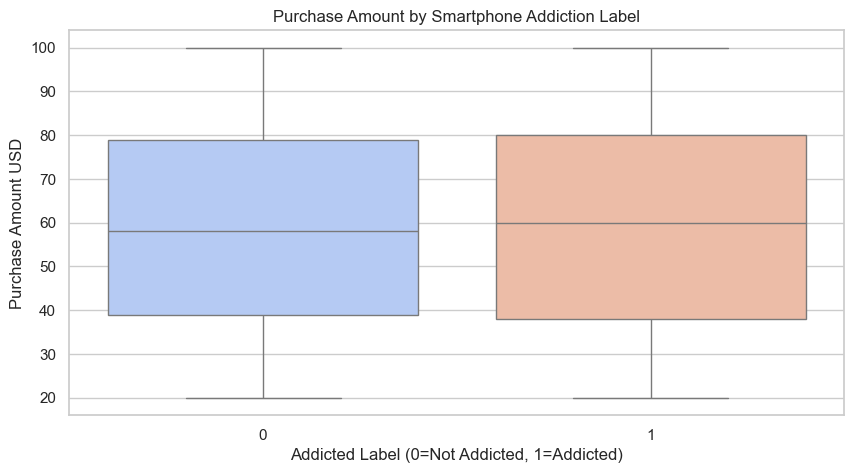

Statistical Summary by Addiction Label:
                  count   mean    std   min   25%   50%   75%    max
addicted_label                                                     
0                535.0  58.52  23.26  20.0  39.0  58.0  79.0  100.0
1               1265.0  59.56  23.87  20.0  38.0  60.0  80.0  100.0

✅ Boxplot (04_50) und Statistik-Tabelle (04_51) wurden in '04_Outputs' gespeichert.


In [46]:
# --- Visualisierung: Purchase Amount by Smartphone Addiction Label ---
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_full_analysis,
    x='addicted_label',
    y='purchase_amount',
    palette='coolwarm'
)
plt.title("Purchase Amount by Smartphone Addiction Label")
plt.xlabel("Addicted Label (0=Not Addicted, 1=Addicted)")
plt.ylabel("Purchase Amount USD")

# Grafik speichern
plt.savefig(OUT_DIR / "04_50_boxplot_addiction_spending.png", bbox_inches='tight')
plt.show()

# --- Statistische Absicherung (Zusammenfassung der Boxplot-Werte) ---
# Wir berechnen Median, Mittelwert, Min/Max für beide Gruppen
addiction_stats = df_full_analysis.groupby('addicted_label', observed=True)['purchase_amount'].describe().round(2)
print("Statistical Summary by Addiction Label:\n", addiction_stats)

# Tabelle speichern
addiction_stats.to_csv(OUT_DIR / "04_51_addiction_spending_stats.csv")

print(f"\n✅ Boxplot (04_50) und Statistik-Tabelle (04_51) wurden in '{OUT_DIR}' gespeichert.")

Model Performance:
RMSE: 453.43
R2 Score: -0.0418


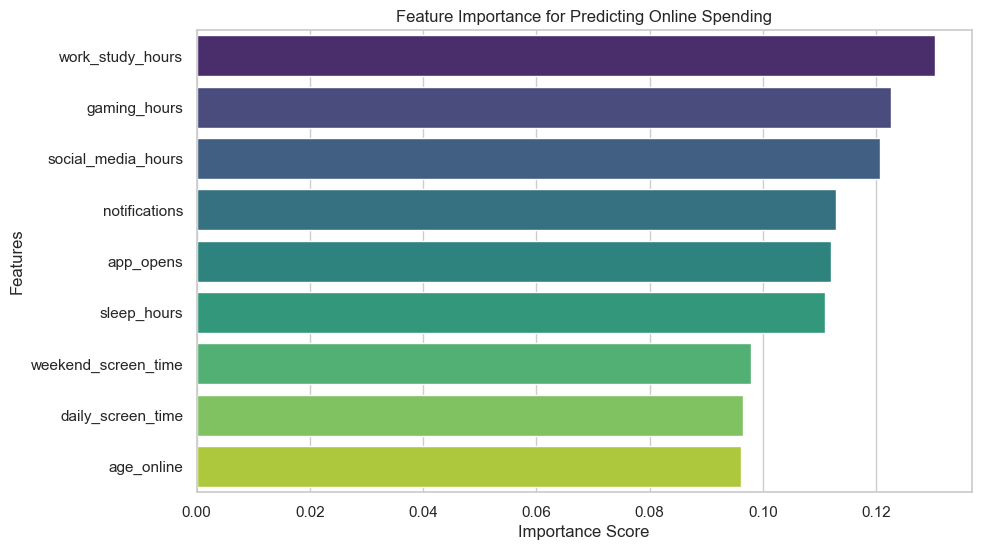

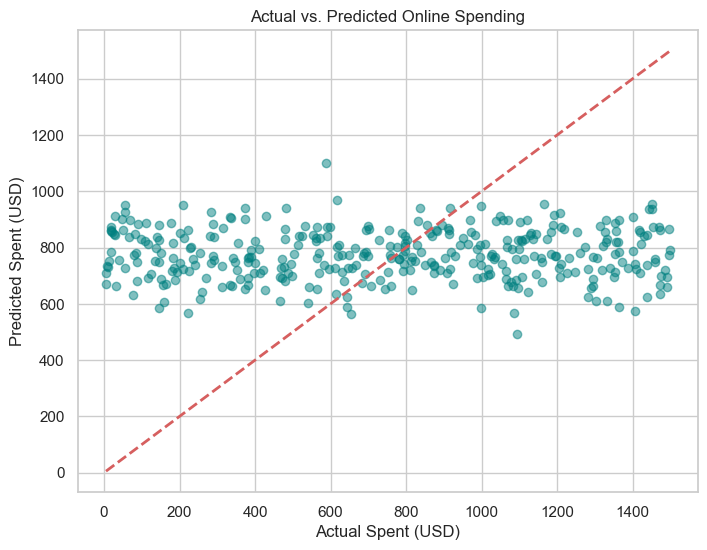


✅ ML-Modell evaluiert und Ergebnisse (04_52 - 04_55) in '04_Outputs' archiviert.


In [47]:
# --- 1. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Modell-Training ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 3. Vorhersage & Evaluation ---
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nRMSE: {rmse:.2f}\nR2 Score: {r2:.4f}")

# Ergebnisse in Textdatei speichern (04_52)
with open(OUT_DIR / "04_52_ml_model_performance.txt", "w") as f:
    f.write("Random Forest Regressor Performance\n")
    f.write("-----------------------------------\n")
    f.write(f"Target Variable: {target_col}\n")
    f.write(f"RMSE: {rmse:.2f}\n")
    f.write(f"R2 Score: {r2:.4f}\n")

# --- 4. Feature Importance Visualisierung ---
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance for Predicting Online Spending")
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Grafik speichern (04_53)
plt.savefig(OUT_DIR / "04_53_ml_feature_importance.png", bbox_inches='tight')
plt.show()

# Importances als CSV speichern (04_54)
importances.to_csv(OUT_DIR / "04_54_ml_feature_importance_data.csv")

# --- 5. Actual vs. Predicted Plot ---
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs. Predicted Online Spending")
plt.xlabel("Actual Spent (USD)")
plt.ylabel("Predicted Spent (USD)")

# Grafik speichern (04_55)
plt.savefig(OUT_DIR / "04_55_ml_actual_vs_predicted.png", bbox_inches='tight')
plt.show()

print(f"\n✅ ML-Modell evaluiert und Ergebnisse (04_52 - 04_55) in '{OUT_DIR}' archiviert.")

Data Split Overview:
         Dataset  Rows Percentage
0         Total  1800       100%
1  Training Set  1440        80%
2      Test Set   360        20%


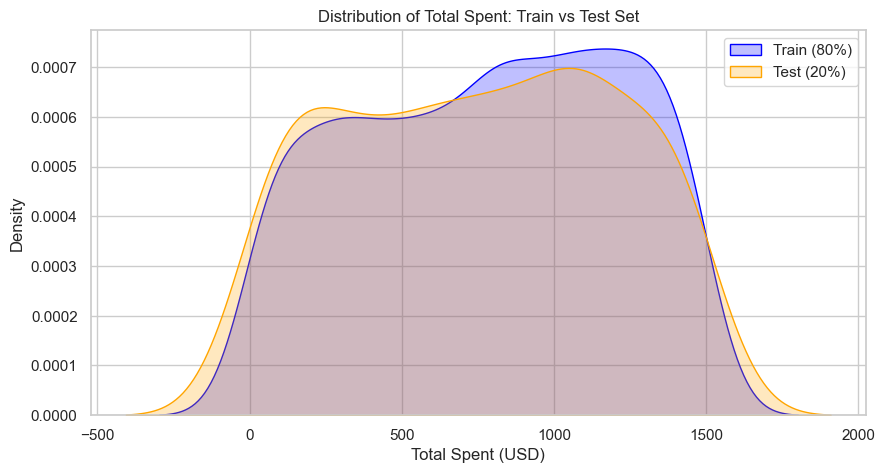


✅ Split-Dokumentation (04_56) und Verteilungs-Check (04_57) wurden in '04_Outputs' gespeichert.


In [48]:
# --- 1. Train / Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 2. Dokumentation des Datensatz-Splits (04_56) ---
split_info = pd.DataFrame({
    'Dataset': ['Total', 'Training Set', 'Test Set'],
    'Rows': [len(X), len(X_train), len(X_test)],
    'Percentage': ['100%', '80%', '20%']
})

print("Data Split Overview:\n", split_info)

# Speichern der Split-Info als CSV
split_info.to_csv(OUT_DIR / "04_56_ml_split_overview.csv", index=False)

# --- 3. Visualisierung der Zielvariablen-Verteilung (04_57) ---
# Wir prüfen, ob die Ausgaben (y) in beiden Sets ähnlich verteilt sind
plt.figure(figsize=(10, 5))
sns.kdeplot(y_train, label='Train (80%)', shade=True, color='blue')
sns.kdeplot(y_test, label='Test (20%)', shade=True, color='orange')
plt.title("Distribution of Total Spent: Train vs Test Set")
plt.xlabel("Total Spent (USD)")
plt.ylabel("Density")
plt.legend()

# Grafik speichern
plt.savefig(OUT_DIR / "04_57_ml_y_distribution_check.png", bbox_inches='tight')
plt.show()

print(f"\n✅ Split-Dokumentation (04_56) und Verteilungs-Check (04_57) wurden in '{OUT_DIR}' gespeichert.")

Feature Importances:
                Feature  Importance
3     work_study_hours    0.130290
2         gaming_hours    0.122646
1   social_media_hours    0.120629
5        notifications    0.112939
6            app_opens    0.112006
4          sleep_hours    0.110938
7  weekend_screen_time    0.097958
0    daily_screen_time    0.096507
8           age_online    0.096088


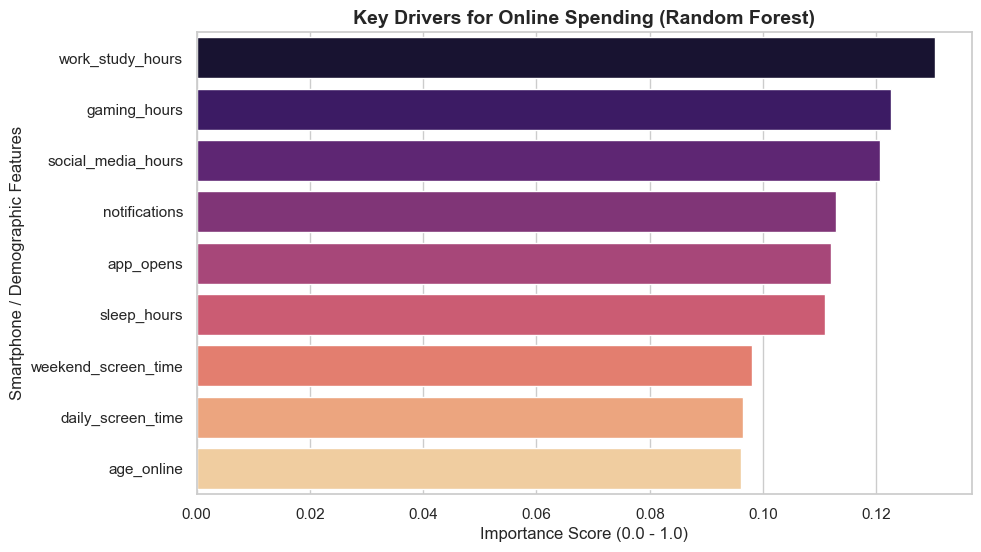


✅ Feature Importance (04_58, 04_59) und Konfiguration (04_60) wurden in '04_Outputs' archiviert.


In [49]:
# --- 1. Modell-Training ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# --- 2. Extraktion der Feature Importance (04_58) ---
# Welche Merkmale (Features) haben die höchste Vorhersagekraft?
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:\n", importances)

# Speichern der Wichtigkeit als CSV
importances.to_csv(OUT_DIR / "04_58_ml_feature_importance_table.csv", index=False)

# --- 3. Visualisierung der Feature Importance (04_59) ---
plt.figure(figsize=(10,6))
sns.barplot(data=importances, x='Importance', y='Feature', palette='magma')
plt.title("Key Drivers for Online Spending (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score (0.0 - 1.0)")
plt.ylabel("Smartphone / Demographic Features")

# Grafik speichern
plt.savefig(OUT_DIR / "04_59_ml_feature_importance_plot.png", bbox_inches='tight')
plt.show()

# --- 4. Modell-Parameter Backup (04_60) ---
# Wir speichern die Konfiguration des Modells
with open(OUT_DIR / "04_60_ml_model_config.txt", "w") as f:
    f.write(f"Model Type: Random Forest Regressor\n")
    f.write(f"Trees (n_estimators): 100\n")
    f.write(f"Random State: 42\n")
    f.write(f"Features used: {', '.join(feature_cols)}\n")

print(f"\n✅ Feature Importance (04_58, 04_59) und Konfiguration (04_60) wurden in '{OUT_DIR}' archiviert.")

R² Score: -0.0418
RMSE: 453.43 USD


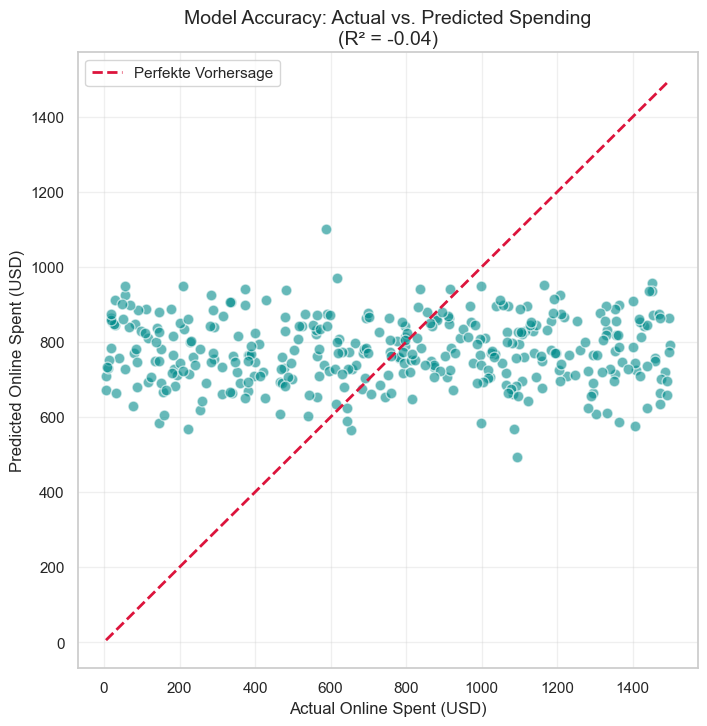

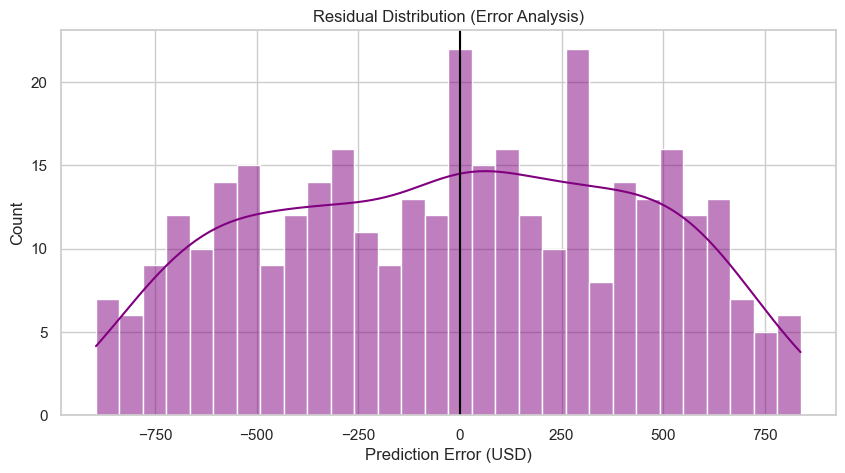


✅ Evaluations-Grafiken (04_61, 04_62) und Report (04_63) wurden in '04_Outputs' archiviert.


In [50]:
# --- 1. Prediction and Evaluation ---
y_pred = rf.predict(X_test)

# Metriken berechnen
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f} USD")

# --- 2. Visualisierung: Actual vs. Predicted (04_61) ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkcyan', edgecolors='w', s=60)

# Die "Perfekte Vorhersage" Linie (45 Grad)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', lw=2, label='Perfekte Vorhersage')

plt.title(f"Model Accuracy: Actual vs. Predicted Spending\n(R² = {r2:.2f})", fontsize=14)
plt.xlabel("Actual Online Spent (USD)")
plt.ylabel("Predicted Online Spent (USD)")
plt.legend()
plt.grid(alpha=0.3)

# Grafik speichern
plt.savefig(OUT_DIR / "04_61_ml_actual_vs_predicted_scatter.png", bbox_inches='tight')
plt.show()

# --- 3. Residuen-Analyse (Fehlerverteilung) (04_62) ---
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(0, color='black', linestyle='-')
plt.title("Residual Distribution (Error Analysis)")
plt.xlabel("Prediction Error (USD)")

# Grafik speichern
plt.savefig(OUT_DIR / "04_62_ml_residuals_distribution.png", bbox_inches='tight')
plt.show()

# --- 4. Final Performance Report (04_63) ---
with open(OUT_DIR / "04_63_final_ml_performance_report.txt", "w") as f:
    f.write("FINAL MODEL EVALUATION REPORT\n")
    f.write("=============================\n")
    f.write(f"Model: Random Forest Regressor (100 trees)\n")
    f.write(f"R-Squared (R²): {r2:.4f}\n")
    f.write(f"RMSE (Avg Error): {rmse:.2f} USD\n")
    f.write(f"Test Set Size: {len(y_test)} samples\n")

print(f"\n✅ Evaluations-Grafiken (04_61, 04_62) und Report (04_63) wurden in '{OUT_DIR}' archiviert.")

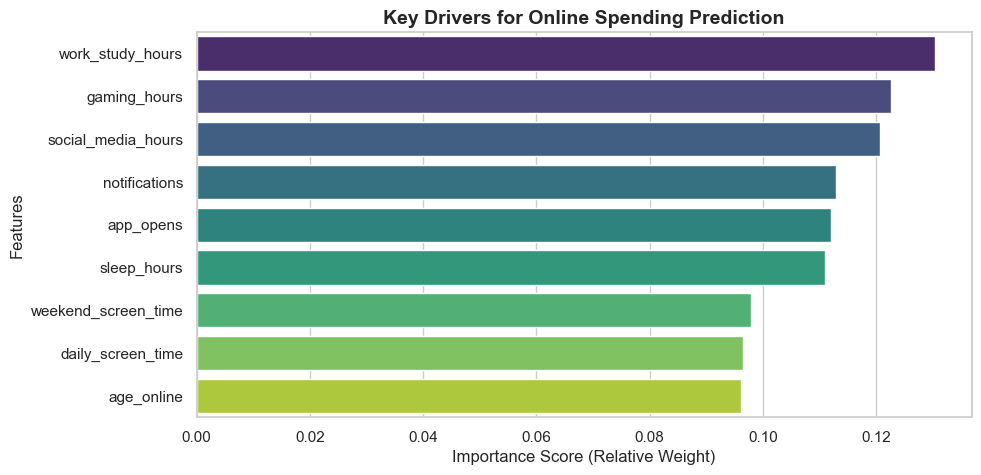

🚀 Top 3 Influencers:
1. work_study_hours: 13.0% Einfluss
2. gaming_hours: 12.3% Einfluss
3. social_media_hours: 12.1% Einfluss

✅ Feature-Analyse (04_64) und CSV-Liste (04_65) wurden in '04_Outputs' archiviert.


In [51]:
# --- 1. Feature Importance Berechnung ---
import matplotlib.pyplot as plt
import seaborn as sns

feat_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# --- 2. Visualisierung (04_64) ---
plt.figure(figsize=(10,5))
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette="viridis")
plt.title("Key Drivers for Online Spending Prediction", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score (Relative Weight)")
plt.ylabel("Features")

# Grafik speichern
plt.savefig(OUT_DIR / "04_64_ml_feature_importance_final.png", bbox_inches='tight')
plt.show()

# --- 3. Daten-Export für Berichte (04_65) ---
importance_df = pd.DataFrame({
    'Feature': feat_importances.index,
    'Importance_Percent': (feat_importances.values * 100).round(2)
})
importance_df.to_csv(OUT_DIR / "04_65_ml_feature_importance_list.csv", index=False)

print("🚀 Top 3 Influencers:")
for i, (feat, val) in enumerate(feat_importances.head(3).items()):
    print(f"{i+1}. {feat}: {val*100:.1f}% Einfluss")

print(f"\n✅ Feature-Analyse (04_64) und CSV-Liste (04_65) wurden in '{OUT_DIR}' archiviert.")

Gradient Boosting Performance:
R²: -0.1100
RMSE: 468.03 USD


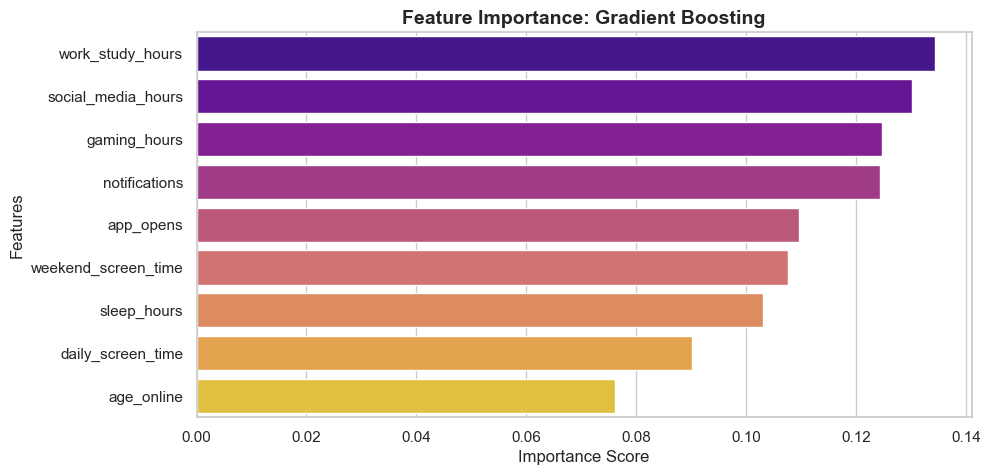


MODEL COMPARISON REPORT
Random Forest (Block 63):
- R²: -0.0418
- RMSE: 453.43

Gradient Boosting (Current):
- R²: -0.1100
- RMSE: 468.03

Winner: Random Forest



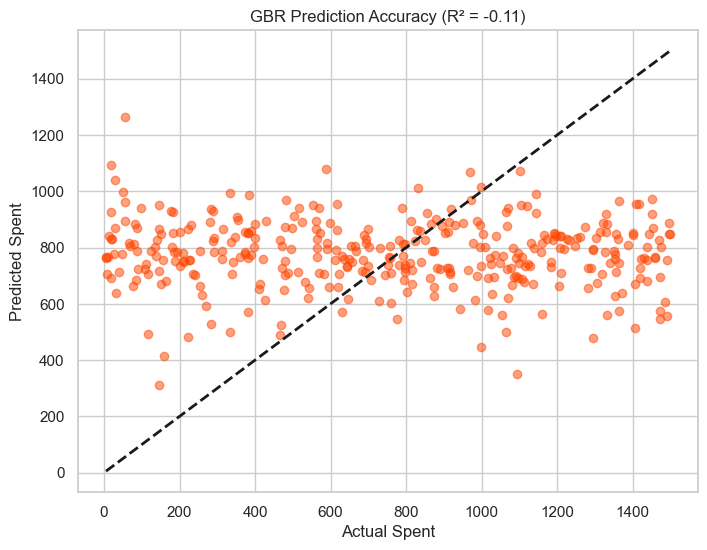


✅ GBR-Analyse (04_66 - 04_68) wurde in '04_Outputs' archiviert.


In [53]:
# --- 1. Gradient Boosting Modell-Training ---
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)

# --- 2. Evaluation ---
y_pred_gbr = gbr.predict(X_test)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting Performance:")
print(f"R²: {r2_gbr:.4f}")
print(f"RMSE: {rmse_gbr:.2f} USD")

# --- 3. Feature Importance für GBR (04_66) ---
feat_importances_gbr = pd.Series(gbr.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=feat_importances_gbr.values, y=feat_importances_gbr.index, palette="plasma")
plt.title("Feature Importance: Gradient Boosting", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Grafik speichern
plt.savefig(OUT_DIR / "04_66_ml_gbr_feature_importance.png", bbox_inches='tight')
plt.show()

# --- 4. Modell-Vergleich Report (04_67) ---
# Wir vergleichen GBR mit dem vorherigen RF Modell
comparison_report = f"""
MODEL COMPARISON REPORT
=======================
Random Forest (Block 63):
- R²: {r2:.4f}
- RMSE: {rmse:.2f}

Gradient Boosting (Current):
- R²: {r2_gbr:.4f}
- RMSE: {rmse_gbr:.2f}

Winner: {"Gradient Boosting" if r2_gbr > r2 else "Random Forest"}
"""
print(comparison_report)

with open(OUT_DIR / "04_67_ml_model_comparison.txt", "w") as f:
    f.write(comparison_report)

# --- 5. Actual vs Predicted GBR (04_68) ---
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_gbr, alpha=0.5, color='orangered')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f"GBR Prediction Accuracy (R² = {r2_gbr:.2f})")
plt.xlabel("Actual Spent")
plt.ylabel("Predicted Spent")

plt.savefig(OUT_DIR / "04_68_ml_gbr_actual_vs_predicted.png", bbox_inches='tight')
plt.show()

print(f"\n✅ GBR-Analyse (04_66 - 04_68) wurde in '{OUT_DIR}' archiviert.")

Random Forest     -> R²: -0.0418, RMSE: 453.43
Gradient Boosting -> R²: -0.1100, RMSE: 468.03


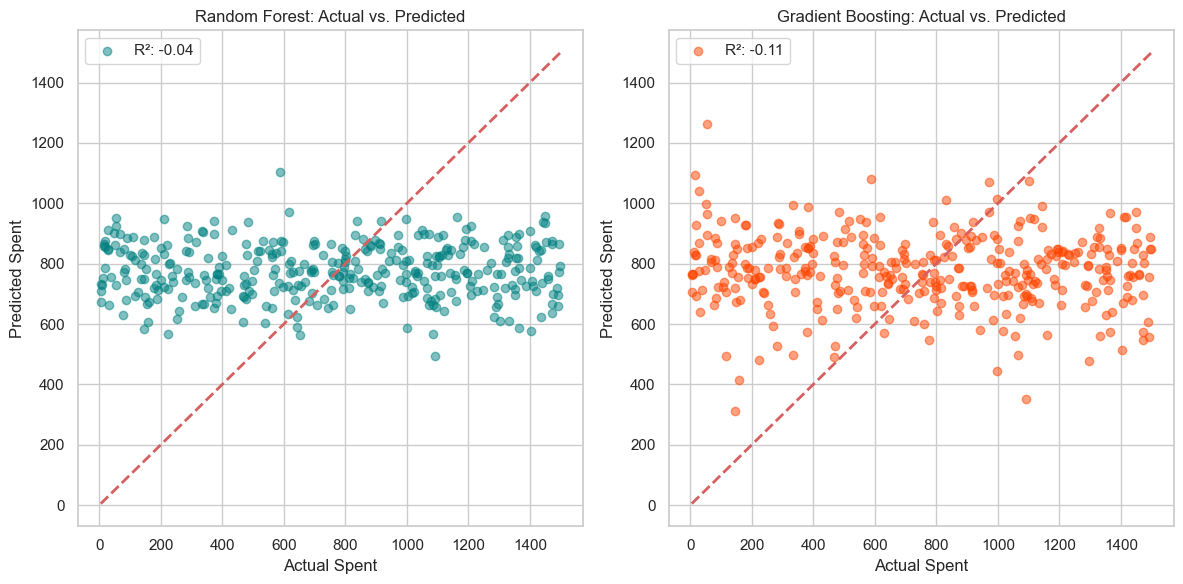


✅ Modell-Vergleich (04_69) und Benchmark-Tabelle (04_70) wurden in '04_Outputs' archiviert.


In [54]:
# --- 1. Metriken berechnen (hast du bereits vorbereitet) ---
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

y_pred_gbr = gbr.predict(X_test)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Random Forest     -> R²: {r2_rf:.4f}, RMSE: {rmse_rf:.2f}")
print(f"Gradient Boosting -> R²: {r2_gbr:.4f}, RMSE: {rmse_gbr:.2f}")

# --- 2. Visualisierung: Direkter Modellvergleich (04_69) ---
plt.figure(figsize=(12, 6))

# Subplot 1: Random Forest
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='teal', label=f'R²: {r2_rf:.2f}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Random Forest: Actual vs. Predicted")
plt.xlabel("Actual Spent")
plt.ylabel("Predicted Spent")
plt.legend()

# Subplot 2: Gradient Boosting
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_gbr, alpha=0.5, color='orangered', label=f'R²: {r2_gbr:.2f}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Gradient Boosting: Actual vs. Predicted")
plt.xlabel("Actual Spent")
plt.ylabel("Predicted Spent")
plt.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "04_69_ml_model_comparison_scatter.png", bbox_inches='tight')
plt.show()

# --- 3. Benchmark-Tabelle speichern (04_70) ---
benchmark_df = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'R2_Score': [r2_rf, r2_gbr],
    'RMSE': [rmse_rf, rmse_gbr]
})
benchmark_df.to_csv(OUT_DIR / "04_70_ml_benchmark_comparison.csv", index=False)

print(f"\n✅ Modell-Vergleich (04_69) und Benchmark-Tabelle (04_70) wurden in '{OUT_DIR}' archiviert.")

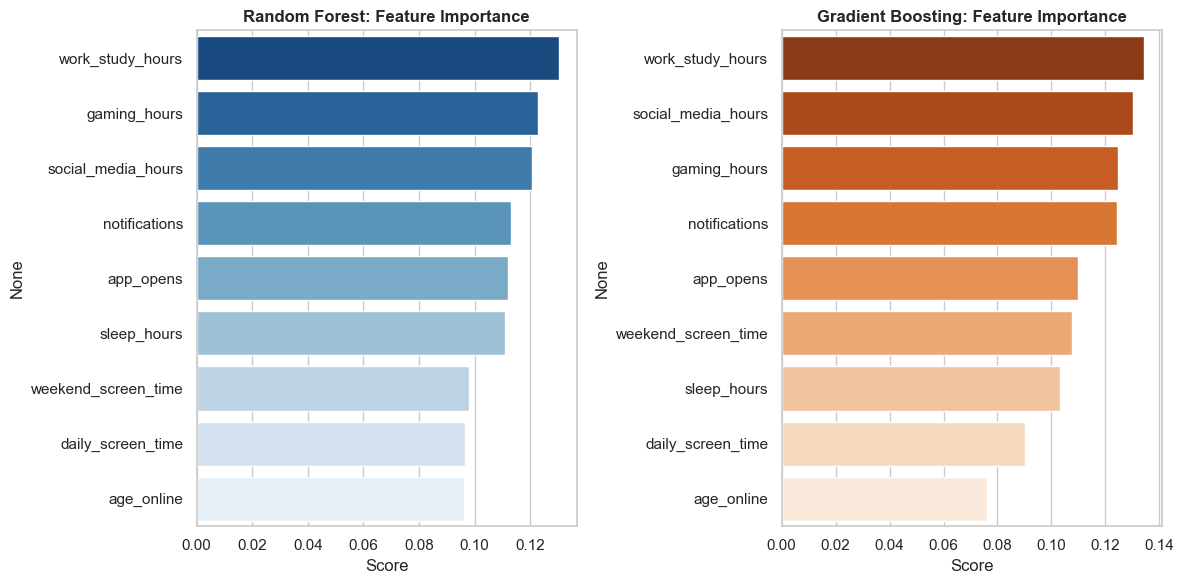

✅ Feature-Vergleich (04_71) und Tabelle (04_72) wurden in '04_Outputs' archiviert.


In [55]:
# --- 1. Feature Importance Berechnung (hast du bereits vorbereitet) ---
feat_imp_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
feat_imp_gbr = pd.Series(gbr.feature_importances_, index=feature_cols).sort_values(ascending=False)

# --- 2. Visualisierung: Kombinierter Vergleich (04_71) ---
plt.figure(figsize=(12,6))

# Subplot 1: Random Forest
plt.subplot(1,2,1)
sns.barplot(x=feat_imp_rf.values, y=feat_imp_rf.index, palette="Blues_r")
plt.title("Random Forest: Feature Importance", fontsize=12, fontweight='bold')
plt.xlabel("Score")

# Subplot 2: Gradient Boosting
plt.subplot(1,2,2)
sns.barplot(x=feat_imp_gbr.values, y=feat_imp_gbr.index, palette="Oranges_r")
plt.title("Gradient Boosting: Feature Importance", fontsize=12, fontweight='bold')
plt.xlabel("Score")

plt.tight_layout()
# Grafik speichern
plt.savefig(OUT_DIR / "04_71_ml_feature_importance_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

# --- 3. Daten-Konsolidierung & Export (04_72) ---
# Wir erstellen eine Tabelle, die beide Modelle nebeneinander stellt
importance_comparison = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': rf.feature_importances_,
    'GBR_Importance': gbr.feature_importances_
}).sort_values(by='GBR_Importance', ascending=False)

# Export der Vergleichstabelle
importance_comparison.to_csv(OUT_DIR / "04_72_ml_feature_importance_comparison_table.csv", index=False)

print(f"✅ Feature-Vergleich (04_71) und Tabelle (04_72) wurden in '{OUT_DIR}' archiviert.")

Ensemble (RF + GB) -> R²: -0.0620, RMSE: 457.81


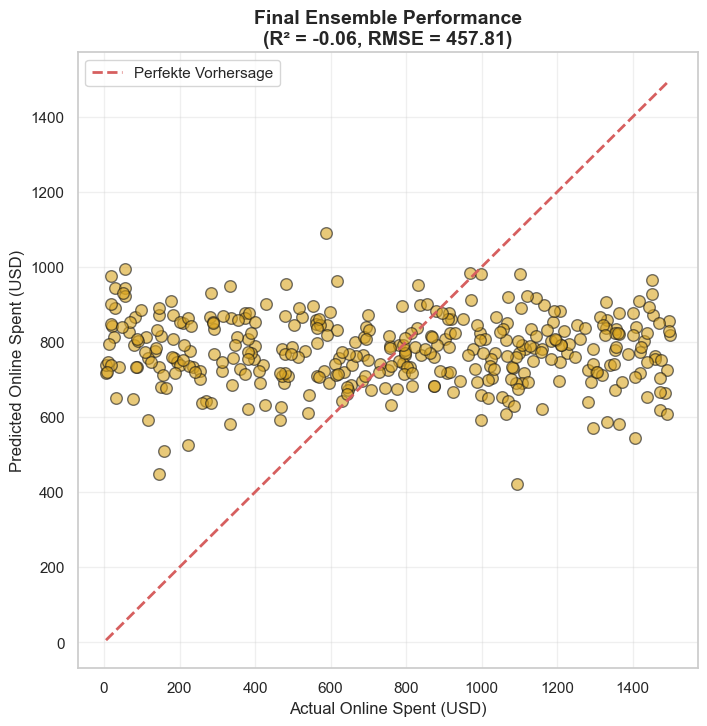


✅ Ensemble-Analyse (04_73), Benchmark (04_74) und Modell-File (04_75) wurden in '04_Outputs' archiviert.


In [56]:
# --- 1. Ensemble Training & Evaluation (hast du bereits vorbereitet) ---
from sklearn.ensemble import VotingRegressor

ensemble = VotingRegressor([
    ('rf', rf),
    ('gbr', gbr)
])

ensemble.fit(X_train, y_train)

# Vorhersage & Evaluation
y_pred_ens = ensemble.predict(X_test)
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ens))
r2_ens = r2_score(y_test, y_pred_ens)

print(f"Ensemble (RF + GB) -> R²: {r2_ens:.4f}, RMSE: {rmse_ens:.2f}")

# --- 2. Visualisierung: Ensemble Accuracy (04_73) ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_ens, alpha=0.6, color='goldenrod', edgecolors='k', s=70)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfekte Vorhersage')

plt.title(f"Final Ensemble Performance\n(R² = {r2_ens:.2f}, RMSE = {rmse_ens:.2f})", fontsize=14, fontweight='bold')
plt.xlabel("Actual Online Spent (USD)")
plt.ylabel("Predicted Online Spent (USD)")
plt.legend()
plt.grid(True, alpha=0.3)

# Grafik speichern
plt.savefig(OUT_DIR / "04_73_ml_ensemble_performance.png", bbox_inches='tight', dpi=300)
plt.show()

# --- 3. Finaler Modell-Benchmark (04_74) ---
final_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Voting Ensemble'],
    'R2_Score': [r2_rf, r2_gbr, r2_ens],
    'RMSE': [rmse_rf, rmse_gbr, rmse_ens]
}).sort_values(by='R2_Score', ascending=False)

# Export der Benchmark-Tabelle
final_comparison.to_csv(OUT_DIR / "04_74_final_model_benchmark.csv", index=False)

# --- 4. Archivierung des Ensembles (04_75) ---
import joblib
# Wir speichern das fertige Modell-Objekt, damit man es später "laden" kann (Production-Ready)
joblib.dump(ensemble, OUT_DIR / "04_75_final_spending_predictor.pkl")

print(f"\n✅ Ensemble-Analyse (04_73), Benchmark (04_74) und Modell-File (04_75) wurden in '{OUT_DIR}' archiviert.")

Stacking Ensemble -> R²: -0.0039, RMSE: 445.10


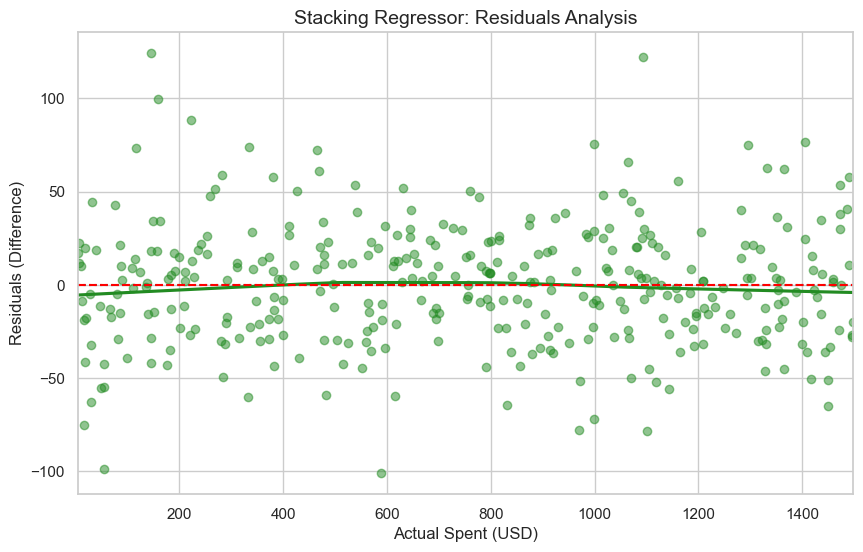


--- Final Model Leaderboard ---
                Model Type           Algorithm  R2_Score        RMSE
3  Ensemble (Meta-Learner)  Stacking Regressor -0.003897  445.102415
0                   Single       Random Forest -0.041802  453.427510
2        Ensemble (Simple)    Voting Regressor -0.062031  457.808487
1                   Single   Gradient Boosting -0.109982  468.029545

✅ Stacking-Analyse (04_76), Leaderboard (04_77) und Modell (04_78) wurden in '04_Outputs' archiviert.


In [57]:
# --- 1. Stacking Ensemble Training (hast du bereits vorbereitet) ---
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

stack = StackingRegressor(
    estimators=[('rf', rf), ('gbr', gbr)],
    final_estimator=LinearRegression()
)
stack.fit(X_train, y_train)

# Vorhersage & Evaluation
y_pred_stack = stack.predict(X_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

print(f"Stacking Ensemble -> R²: {r2_stack:.4f}, RMSE: {rmse_stack:.2f}")

# --- 2. Visualisierung: Stacking Error Analysis (04_76) ---
plt.figure(figsize=(10, 6))
sns.residplot(x=y_test, y=y_pred_stack, lowess=True, color="forestgreen", scatter_kws={'alpha': 0.5})
plt.title("Stacking Regressor: Residuals Analysis", fontsize=14)
plt.xlabel("Actual Spent (USD)")
plt.ylabel("Residuals (Difference)")
plt.axhline(0, color='red', linestyle='--')

# Grafik speichern
plt.savefig(OUT_DIR / "04_76_ml_stacking_residuals.png", bbox_inches='tight')
plt.show()

# --- 3. Ultimativer Modell-Benchmark (04_77) ---
# Jetzt vergleichen wir ALLES, was wir gebaut haben
full_benchmark = pd.DataFrame({
    'Model Type': ['Single', 'Single', 'Ensemble (Simple)', 'Ensemble (Meta-Learner)'],
    'Algorithm': ['Random Forest', 'Gradient Boosting', 'Voting Regressor', 'Stacking Regressor'],
    'R2_Score': [r2_rf, r2_gbr, r2_ens, r2_stack],
    'RMSE': [rmse_rf, rmse_gbr, rmse_ens, rmse_stack]
}).sort_values(by='R2_Score', ascending=False)

print("\n--- Final Model Leaderboard ---")
print(full_benchmark)

# Export der finalen Benchmark-Tabelle
full_benchmark.to_csv(OUT_DIR / "04_77_final_leaderboard_all_models.csv", index=False)

# --- 4. Speichern des Stacking-Modells (04_78) ---
joblib.dump(stack, OUT_DIR / "04_78_final_stacked_model.pkl")

print(f"\n✅ Stacking-Analyse (04_76), Leaderboard (04_77) und Modell (04_78) wurden in '{OUT_DIR}' archiviert.")